In [1]:
## For tutorial #1, we will use a previously analyzed data set so we can load parameters from a config file.
    ## In this tutorial script, we will initialize a Drone_Data and Corr_Data class.
    ## Then, we will combine them into a CONCAT class and use some plotting functions.
    ## Be sure to install the python package according to the instructions in the readme prior to running!
    ## I've tried to heavily comment this in pursuit of two objectives:
        ## 1) The thought process behind how and when we use these functions
        ## 2) To illustrate how/why we tune variables and parameters when needed

## Here is a list of objectives for this tutorial. Try to find (cmd-f) these numbers in the commented sections:
    # 1)  - Import our class functions and verify installation
    # 2)  - Load Drone Data
    # 3)  - Load Correlator Data
    # 4)  - Initialize a concat class for a PULSED GRID FLIGHT
    # 5)  - Perform a series of analysis functions on the concat class...
    # 5A) - concat Function: Extract_Source_Pulses
    # 5B) - concat Function: Perform_Background_Subtraction
    # 5C) - concat Function: Synchronization_Function
    # 5D) - concat Function: Export_yaml
    # 5E) - concat Function: Main_Beam_Fitting

In [2]:
## OBJECTIVE 1: Import our class functions and verify installation

%load_ext autoreload
%autoreload 2

## First import general packages for running python analysis:
import os
import numpy as np
from matplotlib.pyplot import *
import h5py
import datetime
import pytz
import astropy

## Then import the beamcals module packages and initialize 'gbosite' class:
from beamcals import corr
from beamcals import concat
from beamcals import drone
from beamcals import bicolog
import beamcals.plotting_utils as pu
import beamcals.fitting_utils as fu
import beamcals.geometry_utils as gu
import beamcals.time_utils as tu
from beamcals.sites import site
import morgan_concat as mc
# wlcsiteEW=site.site('../beamcals/beamcals/sites/WLC_config_EW20230519.npz')
# wlcsiteNS=site.site('../beamcals/beamcals/sites/WLC_config_NS20230519.npz')
wlcsite = site.site('../beamcals/beamcals/sites/WLC_config.npz')
# wlcsiteEW = site.site('../beamcals/beamcals/sites/WLC_config_EW20250204.npz')
# wlcsiteNS = site.site('../beamcals/beamcals/sites/WLC_config_NS20250204.npz')
wlcsiteEW = site.site('../beamcals/beamcals/sites/WLC_config_EW20250219.npz')
wlcsiteNS = site.site('../beamcals/beamcals/sites/WLC_config_NS20250219.npz')

# wlcsiteEW = site.site('../beamcals/beamcals/sites/WLC_config_EW20250226.npz')
# wlcsiteNS = site.site('../beamcals/beamcals/sites/WLC_config_NS20250226.npz')

In [61]:
## CHANGELOG:
## 02/25 Synchronization tests were successful, function added to synchronize data from drone and correlator
## 03/01 yaml config file tests were successful, need to write config saving script
## 03/08 Writing yaml config files to speed up loading times and reuse parameters found via iterative fitting...
## 03/09 Writing yaml interpreter that searches for the existing params when an init is called

from matplotlib.pyplot import *
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator
import numpy as np
import h5py
import hdf5plugin
import os
import glob
from matplotlib import colors
import pandas
import csv
import datetime
import pytz
import bisect
import pygeodesy
import yaml
from scipy.signal import square
from scipy.stats import pearsonr
from scipy.interpolate import interp1d

## Import packages from our own module:
from beamcals import corr
from beamcals import drone
from beamcals import bicolog
import beamcals.plotting_utils as pu
import beamcals.fitting_utils as fu
import beamcals.geometry_utils as gu
import beamcals.time_utils as tu
## What could go wrong? ...
# from beamcals import concat

class CONCAT:
    def __init__(self,CORRDATCLASS,DRONEDATCLASS,config_directory="/hirax/GBO_Analysis_Outputs/concat_config_files/",output_directory='/hirax/GBO_Analysis_Outputs/',load_yaml=True,traceback=True,save_traceback=True, t_drone_offset = 0):
        ## Decide whether or not we want a traceback for print statements/verification plots:
        self.traceback=traceback
        ## Decide whether or not we want to save traceback output plots:
        self.save_traceback=save_traceback
        ## Import file information from both corr and drone classes:
        self.name=DRONEDATCLASS.name
        self.Data_Directory=CORRDATCLASS.Data_Directory
        self.Gain_Directory=CORRDATCLASS.Gain_Directory
        self.filenames=CORRDATCLASS.filenames
        self.gainfile=CORRDATCLASS.gainfile
        self.Drone_Directory=DRONEDATCLASS.Drone_Directory
        self.FLYTAG=DRONEDATCLASS.FLYTAG
        ## YAML configuration variables and config parameter loading:
        self.Config_Directory=config_directory
        self.load_yaml=load_yaml
        if self.traceback==True:
            print('Initializing CONCAT CLASS with active traceback using:')
            print("  --> "+CORRDATCLASS.Data_Directory)
            print("  --> "+DRONEDATCLASS.FLYTAG)
            if self.save_traceback==True:
                print('Creating directory for saving traceback and analysis outputs:')
                if 'TONE_ACQ' in self.Data_Directory:
                    tmpcorrdir=self.Data_Directory.split("_yale")[0].split("TONE_ACQ/")[1]
                elif 'NFandFF' in self.Data_Directory:
                    tmpcorrdir=self.Data_Directory.split("_Suit")[0].split("NFandFF/")[1]
                tmpdronedir=self.FLYTAG.split('.')[0]
                tmpoutputdir=output_directory+'{}_{}'.format(tmpdronedir,tmpcorrdir)+'/'
                if os.path.exists(tmpoutputdir)==False:                
                    self.Output_Directory=tmpoutputdir
                    self.Output_Prefix='{}_{}'.format(tmpdronedir,tmpcorrdir)
                if os.path.exists(tmpoutputdir)==True:
                    suff=datetime.datetime.now().strftime("%Y%m%dT%H%M%S")
                    self.Output_Prefix='{}_{}_ver_{}'.format(tmpdronedir,tmpcorrdir,suff)
                    self.Output_Directory=output_directory+'{}_{}_ver_{}'.format(tmpdronedir,tmpcorrdir,suff)+'/'
                os.makedirs(self.Output_Directory)
                print("  --> "+self.Output_Directory)
            if self.save_traceback==False:
                print("  --> Traceback outputs will not be saved...")
        elif self.traceback==False:
            pass
        ## If we don't want to load previous yaml config files, we skip the yaml interpreter:
        if self.load_yaml==False:
            if self.traceback==True:
                print('Concat initialized without previous config file...')
            if traceback==False:
                pass
        ## If we DO want to load previous config files, we enter this loop:
        if self.load_yaml==True:
            ## First we check if a config has previously been saved using these two data sets:
            if 'TONE_ACQ' in self.Data_Directory:
                tmpcorrdir=self.Data_Directory.split("_yale")[0].split("TONE_ACQ/")[1]
            elif 'NFandFF' in self.Data_Directory:
                tmpcorrdir=self.Data_Directory.split("_Suit")[0].split("NFandFF/")[1]
            tmpdronedir=self.FLYTAG.split('.')[0]
            tmpconfigpath=self.Config_Directory+'config_{}_{}.yaml'.format(tmpdronedir,tmpcorrdir)
            self.yaml_exists=os.path.exists(tmpconfigpath)
            ## If the previous config file doesn't exist, we will tell the user and move on:
            if self.yaml_exists==False:
                ## Check to see if we are going to use some print statements:
                if self.traceback==True:
                    print('Searching for previous config file:')
                    print('  --> Checking directory for config_{}_{}.yaml:'.format(tmpdronedir,tmpcorrdir))
                    print('    --> FILE NOT FOUND')
                    print('    --> Parameters can not be imported...')
                if self.traceback==False:
                    pass
            ## If the previous config file exists, we enter this loop to load parameters:
            if self.yaml_exists==True:
                ymlfile=open(self.Config_Directory+'config_{}_{}.yaml'.format(tmpdronedir,tmpcorrdir))
                #documents=yaml.full_load(ymlfile)
                with open(ymlfile, 'r') as fff:
                    documents = yaml.safe_load(fff)
                ## Check to see if the variables exist for function: Extract_Source_Pulses
                if 'pulse_params' in documents.keys():
                    self.pulse_period=np.float64(documents["pulse_params"]["pulse_period"])
                    self.pulse_dutycycle=np.float64(documents["pulse_params"]["pulse_dutycycle"])
                    self.t_delta_pulse=np.float64(documents["pulse_params"]["t_delta_pulse"])
                ## Check to see if the variables exist for function: Synchronization_Function
                if 'timing_params' in documents.keys():
                    self.t_delta_dji=np.float64(documents["timing_params"]["t_delta_dji"])
                    self.copolchan=documents["timing_params"]["copolchan"]
                ymlfile.close() # close the config file
                if self.traceback==True:
                    print('Searching for previous config file:')
                    print('  --> Checking directory for config_{}_{}.yaml:'.format(tmpdronedir,tmpcorrdir))
                    print('    --> FILE EXISTS')
                    print('    --> Loading existing config file parameters...')
                    if hasattr(self,"pulse_period")==True:
                        print('      --> pulse_period = {}'.format(self.pulse_period))
                    if hasattr(self,"pulse_dutycycle")==True:
                        print('      --> pulse_dutycycle = {}'.format(self.pulse_dutycycle))
                    if hasattr(self,"t_delta_pulse")==True:
                        print('      --> t_delta_pulse = {}'.format(self.t_delta_pulse))                        
                    if hasattr(self,"t_delta_dji")==True:
                        print('      --> t_delta_dji = {}'.format(self.t_delta_dji)) 
                    if hasattr(self,"copolchan")==True:
                        print('      --> copolchan = {}'.format(self.copolchan))
                if self.traceback==False:
                    pass
        ## Import vars from corr and drone classes:
        self.n_dishes=CORRDATCLASS.n_dishes
        self.n_channels=CORRDATCLASS.n_channels
        self.chmap=CORRDATCLASS.chmap
        self.automap=CORRDATCLASS.automap
        self.crossmap=CORRDATCLASS.crossmap
        self.origin=DRONEDATCLASS.origin
        self.prime_origin=DRONEDATCLASS.prime_origin
        self.dish_keystrings=DRONEDATCLASS.dish_keystrings
        self.dish_coords=DRONEDATCLASS.dish_coords
        self.dish_pointings=DRONEDATCLASS.dish_pointings
        self.dish_polarizations=DRONEDATCLASS.dish_polarizations
        ## Time dimensions of all arrays must be concat with receiver data. Time index is therefore defined wrt telescope data.
        self.freq=CORRDATCLASS.freq
        self.t=CORRDATCLASS.t
        self.t_index=CORRDATCLASS.t_index
        self.t_arr_datetime=CORRDATCLASS.t_arr_datetime
        self.V=CORRDATCLASS.V
        self.V_cross=CORRDATCLASS.V_cross
        ## Define lb and ub t_index corresponding to drone data start/stop times:
        drone_t_min=DRONEDATCLASS.t_arr_datetime[0]
        drone_t_max=DRONEDATCLASS.t_arr_datetime[-1]
        CORR_t_ind_lb=bisect.bisect_right(self.t_arr_datetime, drone_t_min)
        CORR_t_ind_ub=bisect.bisect_left(self.t_arr_datetime, drone_t_max)
        ## Define interpolation time vectors for drone and corr data:
        tsepoch=datetime.datetime.utcfromtimestamp(0).replace(tzinfo=pytz.UTC)
        ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])
        ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])
        ds_drone = ds_drone+t_drone_offset
        #ds_CORR=[(self.t_arr_datetime[n]-self.t_arr_datetime[CORR_t_ind_lb]).total_seconds() for n in self.t_index[CORR_t_ind_lb:CORR_t_ind_ub]]
        #ds_drone=[(DRONEDATCLASS.t_arr_datetime[m]-drone_t_min).total_seconds() for m in DRONEDATCLASS.t_index]
        if self.traceback==True:
            print("Interpolating drone coordinates for each correlator timestamp:")
            print("  --> correlator timestamp axis contains {} elements".format(len(ds_CORR)))
            print("  --> drone timestamp axis contains {} elements".format(len(ds_drone)))
        elif self.traceback==False:
            pass
        ## Create useful drone coordinate arrays which we must interp, NAN non valued elements:
        self.drone_llh_interp=np.nan*np.ones((self.t_arr_datetime.shape[0],3))
        self.drone_xyz_LC_interp=np.nan*np.ones((self.t_arr_datetime.shape[0],3))
        self.drone_rpt_interp=np.nan*np.ones((self.t_arr_datetime.shape[0],3))
        self.drone_yaw_interp=np.nan*np.ones(self.t_arr_datetime.shape[0])
        self.drone_xyz_per_dish_interp=np.nan*np.ones((DRONEDATCLASS.xyz_per_dish.shape[0],self.t_arr_datetime.shape[0],3))
        self.drone_rpt_r_per_dish_interp=np.nan*np.ones((DRONEDATCLASS.rpt_r_per_dish.shape[0],self.t_arr_datetime.shape[0],3))
        self.drone_rpt_t_per_dish_interp=np.nan*np.ones((DRONEDATCLASS.rpt_r_per_dish.shape[0],self.t_arr_datetime.shape[0],3))
        ## Interp Drone variables:
        for i in [0,1,2]:
            self.drone_llh_interp[CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.coords_llh[:,i])
            self.drone_xyz_LC_interp[CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.coords_xyz_LC[:,i])
            self.drone_rpt_interp[CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.coords_rpt[:,i])
            for j in range(DRONEDATCLASS.rpt_r_per_dish.shape[0]):            
                self.drone_xyz_per_dish_interp[j,CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.xyz_per_dish[j,:,i])
                self.drone_rpt_r_per_dish_interp[j,CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.rpt_r_per_dish[j,:,i])
                self.drone_rpt_t_per_dish_interp[j,CORR_t_ind_lb:CORR_t_ind_ub,i]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.rpt_t_per_dish[j,:,i])
        self.drone_yaw_interp[CORR_t_ind_lb:CORR_t_ind_ub]=np.interp(ds_CORR,ds_drone,DRONEDATCLASS.yaw[:])
        self.tstep=1e-9*np.nanmedian(np.diff(self.t))

    def Extract_Source_Pulses(self,Period=0.4e6,Dutycycle=0.2e6,t_bounds=[0,-1],f_ind=900,minmaxpercents=[10.0,99.5]):
        ## Search for all three timing variables that must be loaded from config:
        if hasattr(self,"pulse_period")==True and hasattr(self,"pulse_dutycycle")==True and hasattr(self,"t_delta_pulse")==True:
            if self.traceback==True:
                print("Extracting Source Pulses using parameters loaded from config file:")
                print('  --> pulse_period = {}'.format(self.pulse_period))                        
                print('  --> pulse_dutycycle = {}'.format(self.pulse_dutycycle))                        
                print('  --> t_delta_pulse = {}'.format(self.t_delta_pulse))
            if self.traceback==False:
                pass
            concat_duration=int(np.ceil((self.t_arr_datetime[-1]-self.t_arr_datetime[0]).total_seconds()))
            time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        ## If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        if hasattr(self,"t_delta_pulse")==False:
            ## Create Switch Signal
            self.pulse_period=Period
            self.pulse_dutycycle=Dutycycle
            concat_duration=int(np.ceil((self.t_arr_datetime[-1]-self.t_arr_datetime[0]).total_seconds()))
            time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
            ## Create t_offset range (1 period) and Pearson_r vars:
            t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)
            Pr_arr=np.NaN*np.ones((self.n_channels,t_offset_dist.shape[0]))
            Pr_max_ind_per_channel=np.NaN*np.ones(self.n_channels)
            Pr_max_t_0_per_channel=np.NaN*np.ones(self.n_channels)
            t_full=np.array([(m-self.t_arr_datetime[0]).total_seconds() for m in self.t_arr_datetime[:]])
            ## Loop over channels to find/plot a time offset solution with some clever fitting:
            if self.traceback==True:
                fig1,ax1=subplots(nrows=1,ncols=1,figsize=(16,4))
            elif self.traceback==False:
                pass
            for i in range(self.n_channels):
                ## If we use a mean subtracted data cut we can find where power exceeds zero to find signal
                minsubdata=self.V[:,f_ind,i]-np.percentile(self.V[:,f_ind,i],minmaxpercents[0])
                normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
                clipnormminsubdata=normminsubdata.clip(0,1)
                stepped_func=interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
                sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
                t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)
                ## Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
                for j,t_offset in enumerate(t_offset_dist):
                    shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                    try:
                        Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]),shiftedswitch[t_restrict])[0]
                    except ValueError:
                        Pr_arr[i,j]=np.nan
                if self.traceback==True:
                    ax1.plot(t_offset_dist,Pr_arr[i,:],'.')
                elif self.traceback==False:
                    pass
                try:
                    maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                    if self.traceback==True:
                        ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')
                    elif self.traceback==False:
                        pass
                    Pr_max_ind_per_channel[i]=maxPrind
                    Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
                except IndexError:
                    Pr_max_ind_per_channel[i]=np.nan
                    Pr_max_t_0_per_channel[i]=np.nan            
            self.t_delta_pulse=np.nanmedian(Pr_max_t_0_per_channel)
            if self.traceback==True:
                ax1.axvline(self.t_delta_pulse,label="selected t_offset")
                ax1.legend(loc=1)
                tight_layout()
                print("Maximum Pearson_R Correlations between data and square wave function:") 
                print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
                print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
                print("Selecting square wave function time offset:")
                print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))
                if self.save_traceback==True:
                    savefig(self.Output_Directory+self.Output_Prefix+"_t_delta_pulse_Pearson_R.png")
                if self.save_traceback==False:
                    pass
            elif self.traceback==False:
                pass
        ## Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        t_for_interp_out=np.array([(m-self.t_arr_datetime[0]).total_seconds() for m in self.t_arr_datetime[:]])
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        ## Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f-0.5)))[0])),\
                                  np.intersect1d(np.where(1.0>switch_interp_f),np.where(switch_interp_f>0.0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1.0)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0.0)[0])-set(self.inds_span))
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        if self.traceback==True:
            print("Finding relevant pulsing indices and checking for overlaps:")        
            print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
            print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
            print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))
            ## Let's plot the on/off/rising index groups:
            fig3=figure(figsize=(16,int(4*self.n_channels/2)))
            for i in range(self.n_channels):
                ax=fig3.add_subplot(int(self.n_channels/2),2,i+1)   
                ax.semilogy(self.t_arr_datetime[:],self.V[:,f_ind,i],'k.',label='all')
                ax.semilogy(self.t_arr_datetime[self.inds_on],self.V[self.inds_on,f_ind,i],'.',label='on')
                ax.semilogy(self.t_arr_datetime[self.inds_off],self.V[self.inds_off,f_ind,i],'.',label='off')   
                ax.semilogy(self.t_arr_datetime[self.inds_span],self.V[self.inds_span,f_ind,i],'x',label='span')
                ax.semilogy(self.t_arr_datetime[:],(np.nanmax(self.V[self.inds_on,f_ind,i])*switch_interp_f)+np.nanmin(self.V[self.inds_on,f_ind,i]),'--',alpha=0.1,label='switch, t_offset={:.2f}'.format(self.t_delta_pulse))
                ax.set_ylabel("Log Power Received [$ADU^2$]")
                ax.set_xlabel("Datetime")
                ax.set_title("Channel {}".format(self.chmap[i]))
                ax.legend(loc=2)
                ax.set_xlim(self.t_arr_datetime[t_bounds[0]],self.t_arr_datetime[t_bounds[1]])
            tight_layout()
            if self.save_traceback==True:
                savefig(self.Output_Directory+self.Output_Prefix+"_t_delta_pulse_index_solution.png")
            if self.save_traceback==False:
                pass            
        if self.traceback==False:
            pass
        
    def Perform_Background_Subtraction(self,window_size=5):
        ## BACKGROUND SUBTRACTED SPECTRA: ##
        if self.traceback==True:
            print("Calculating background spectra from indices where the noise source is off.")
        if self.traceback==False:
            pass
        self.V_bg=np.zeros(self.V.shape)
        self.V_bgsub=np.zeros(self.V.shape)
        if self.crossmap!=None:
            self.V_cross_bg=np.zeros(self.V_cross.shape).astype(complex)
            self.V_cross_bgsub=np.zeros(self.V_cross.shape).astype(complex)
        ## Loop over all indices and construct the V_bg array:
        for k,ind in enumerate(self.t_index):
            ## If ind is an off spectra, use this off spectra for the background:
            if k in self.inds_off:
                self.V_bg[k,:,:]=self.V[k,:,:]
                if self.crossmap!=None:
                    self.V_cross_bg[k,:,:]=self.V_cross[k,:,:]
            ## If ind is an on spectra, create an off spectra by averaging the before/after off spectra:
            elif k in np.union1d(self.inds_on,self.inds_span):
                t_window=np.intersect1d(np.arange(k-window_size,k+window_size),self.inds_off)
                self.V_bg[k,:,:]=np.nanmean(self.V[t_window,:,:],axis=0)
                if self.crossmap!=None:
                    self.V_cross_bg[k,:,:]=np.nanmean(self.V_cross[t_window,:,:],axis=0)
        self.V_bgsub=self.V-self.V_bg
        if self.crossmap!=None:
            self.V_cross_bgsub=self.V_cross-self.V_cross_bg
        if self.traceback==True:
            print("  --> Background subtraction completed using window_size = {}".format(window_size))
        if self.traceback==False:
            pass
        
    def Synchronization_Function(self,inputcorr,inputdrone,coarse_params=[-10.0,10.0,0.2],fine_params=[-0.5,0.5,0.01],chans=np.array([0,1]),freqs=np.arange(100,1024,150),FMB_coordbounds=[30.0,30.0,150.0],FMB_ampbound=0.999):
        if self.traceback==True:
            print("Synchronizing data from correlator and drone:")
        if self.traceback==False:
            pass
        ## Begin by checking if the t_delta_dji parameter was already loaded from the config file:
        if hasattr(self,"t_delta_dji")==True:
            if self.traceback==True:
                print('  --> Loading parameter from existing configuration file: t_delta_dji = {}'.format(self.t_delta_dji))
                print("Applying a time correction of {:.2f} seconds using Channel {} fits.".format(self.t_delta_dji,self.copolchan))
            if self.traceback==False:
                pass
        if hasattr(self,"t_delta_dji")==False:
            if self.traceback==True:
                print("  --> Previous t_delta_dji not found") 
                print("  --> Calculating via 2DGauss fitting routine:")
            if self.traceback==False:
                pass
            ## Begin with specifying time axis for iteration:
            t_coarse=np.arange(coarse_params[0],coarse_params[1],coarse_params[2])
            ## Define output products from fits:
            AFit_f_params=np.zeros((len(t_coarse),len(chans),len(freqs),5))
            APRarr=np.zeros((len(t_coarse),len(chans),len(freqs)))
            GFit_f_params=np.zeros((len(t_coarse),len(chans),len(freqs),7))
            GPRarr=np.zeros((len(t_coarse),len(chans),len(freqs)))
#             print(GPRarr.shape)
            ## Begin iterative loop for coarse time axis:
            for i,ttry in enumerate(t_coarse):
                origtaxis=inputdrone.t_arr_datetime[:]
                tempdrone=inputdrone
                tempdrone.t_arr_datetime=inputdrone.t_arr_datetime+datetime.timedelta(seconds=ttry)
                tempconcat=CONCAT(CORRDATCLASS=inputcorr,DRONEDATCLASS=tempdrone,load_yaml=False,traceback=False,save_traceback=False)
                try:
                    tempconcat.inds_on=self.inds_on
                except AttributeError:
                    pass
                inputdrone.t_arr_datetime=origtaxis
                ## Run fits:
                result=fu.Fit_Main_Beam(tempconcat,chans,freqs,theta_solve=False,coordbounds=FMB_coordbounds,ampbound=FMB_ampbound)
                AFit_f_params[i]=result[0]
                APRarr[i]=result[1]
                GFit_f_params[i]=result[2]
                GPRarr[i]=result[3]
            ## Loop over the channels and frequencies to find the index that maximizes the Pearson R Array:
            GPRmax=np.zeros((len(chans),len(freqs)))
            GPRval=np.zeros((len(chans),len(freqs)))
#             print(GPRval.shape)
#             print(GPRval)
            for i in range(len(chans)):
                for j in range(len(freqs)):
                    try:
                        GPRmax[i,j]=np.where(GPRarr[:,i,j]==np.nanmax(GPRarr[:,i,j]))[0][0]
                        GPRval[i,j]=GPRarr[int(GPRmax[i,j]),i,j]
                    except IndexError:
                        GPRmax[i,j]=np.nan
                        GPRval[i,j]=np.nan
            print(GPRval)
            copolchan=np.where(np.nanmean(GPRval,axis=1)==np.nanmax(np.nanmean(GPRval,axis=1)))[0][0]
            print(f"copolchan={copolchan}")
            ## Redefine time axis for fine resolution:
            tfine0=t_coarse[int(np.nanmedian(GPRmax[copolchan,:]))]
            t_fine=np.arange(tfine0+fine_params[0],tfine0+fine_params[1],fine_params[2])
            ## Define output products from fine resolution fits:
            AFit_f_params_fine=np.zeros((len(t_fine),len(chans),len(freqs),5))
            APRarr_fine=np.zeros((len(t_fine),len(chans),len(freqs)))
            GFit_f_params_fine=np.zeros((len(t_fine),len(chans),len(freqs),7))
            GPRarr_fine=np.zeros((len(t_fine),len(chans),len(freqs)))
            ## Begin iterative loop for coarse time axis:    
            for i,ttry in enumerate(t_fine):
                origtaxis=inputdrone.t_arr_datetime[:]
                tempdrone=inputdrone
                tempdrone.t_arr_datetime=inputdrone.t_arr_datetime+datetime.timedelta(seconds=ttry)
                tempconcat=CONCAT(CORRDATCLASS=inputcorr,DRONEDATCLASS=tempdrone,load_yaml=False,traceback=False,save_traceback=False)
                try:
                    tempconcat.inds_on=self.inds_on
                except AttributeError:
                    pass
                inputdrone.t_arr_datetime=origtaxis
                ## Run fits:
                result=fu.Fit_Main_Beam(tempconcat,chans,freqs,theta_solve=False,coordbounds=FMB_coordbounds,ampbound=FMB_ampbound)
                AFit_f_params_fine[i]=result[0]
                APRarr_fine[i]=result[1]
                GFit_f_params_fine[i]=result[2]
                GPRarr_fine[i]=result[3]
            ## Find the maximal Pearson R values for the fine time axis:
            GPRmax_fine=np.zeros((len(chans),len(freqs)))
            GPRval_fine=np.zeros((len(chans),len(freqs)))
            for i in range(len(chans)):
                for j in range(len(freqs)):
                    try:
                        GPRmax_fine[i,j]=np.where(GPRarr_fine[:,i,j]==np.nanmax(GPRarr_fine[:,i,j]))[0][0]
                        GPRval_fine[i,j]=GPRarr_fine[int(GPRmax_fine[i,j]),i,j]
                    except IndexError:
                        GPRmax_fine[i,j]=np.nan
                        GPRval_fine[i,j]=np.nan
            ## Which channel has the best gaussianity, and what time offset does that channel suggest?
            copolchan_fine=np.where(np.nanmean(GPRval_fine,axis=1)==np.nanmax(np.nanmean(GPRval_fine,axis=1)))[0][0]
            self.t_delta_dji=t_fine[int(np.nanmedian(GPRmax_fine[copolchan_fine,:]))]
            self.copolchan=copolchan_fine
            ## Now make plots if desired:
            if self.traceback==True:
                print("Applying a time correction of {:.2f} seconds using Channel {} fits.".format(self.t_delta_dji,self.copolchan))
                fig0,[ax1,ax2]=subplots(nrows=2,ncols=1,figsize=(16,12))
                i=0
                for k,find in enumerate(freqs):
                    ax1.plot(t_coarse,GPRarr[:,i,k],label='{:.2f}MHz'.format(tempconcat.freq[find]))
                    ax1.plot(t_coarse[int(GPRmax[i,k])],GPRarr[int(GPRmax[i,k]),i,k],'r.')
                ax1.axvline(t_coarse[int(np.nanmedian(GPRmax[i]))],c='r',label='median t = {:.2f}'.format(t_coarse[int(np.nanmedian(GPRmax[i]))]))
                ax1.set_title('Channel {} Coarse Offset Correlation'.format(chans[i]))
                ax1.set_xlabel('$\Delta$t $[sec]$')
                ax1.set_ylabel('Pearson R Value')
                ax1.legend(loc=1,fontsize='small')
                for k,find in enumerate(freqs):
                    ax2.plot(t_fine,GPRarr_fine[:,i,k],label='{:.2f}MHz'.format(tempconcat.freq[find]))
                    ax2.plot(t_fine[int(GPRmax_fine[i,k])],GPRarr_fine[int(GPRmax_fine[i,k]),i,k],'r.')
                ax2.axvline(t_fine[int(np.nanmedian(GPRmax_fine[i]))],c='r',label='median t = {:.2f}'.format(t_fine[int(np.nanmedian(GPRmax_fine[i]))]))
                ax2.set_title('Channel {} Coarse Offset Correlation'.format(chans[i]))
                ax2.set_xlabel('$\Delta$t $[sec]$')
                ax2.set_ylabel('Pearson R Value')
                ax2.legend(loc=1,fontsize='small')
                tight_layout()
                if self.save_traceback==True:
                    savefig(self.Output_Directory+self.Output_Prefix+"_t_delta_dji_Pearson_R.png")
                if self.save_traceback==False:
                    pass
            elif self.traceback==False:
                pass
        ## END of config interpretation loop!
        ## Now shift the drone time axis by t_delta_dji and reinterpolate the coordinates, then reassign the variables:
        origtaxis=inputdrone.t_arr_datetime[:]
        tempdrone=inputdrone
        tempdrone.t_arr_datetime=inputdrone.t_arr_datetime+datetime.timedelta(seconds=self.t_delta_dji)
        tempconcat=CONCAT(CORRDATCLASS=inputcorr,DRONEDATCLASS=tempdrone,load_yaml=False,traceback=False,save_traceback=False)
        self.drone_llh_interp=tempconcat.drone_llh_interp
        self.drone_xyz_LC_interp=tempconcat.drone_xyz_LC_interp
        self.drone_rpt_interp=tempconcat.drone_rpt_interp
        self.drone_yaw_interp=tempconcat.drone_yaw_interp
        self.drone_xyz_per_dish_interp=tempconcat.drone_xyz_per_dish_interp
        self.drone_rpt_r_per_dish_interp=tempconcat.drone_rpt_r_per_dish_interp
        self.drone_rpt_t_per_dish_interp=tempconcat.drone_rpt_t_per_dish_interp
        inputdrone.t_arr_datetime=origtaxis
        if self.traceback==True:
            print('  --> Variable synchronation successful, generating output plots:')
            channels=chans
            print(channels)
            pu.Synchronization_Verification_Plots(inputconcat=self,chans=channels,find=freqs[-1],coordbounds=FMB_coordbounds,ampbound=FMB_ampbound)
            if self.save_traceback==True:
                print('  --> Saving output plot.')
                savefig(self.Output_Directory+self.Output_Prefix+"_Synchronization_Verification.png")
            if self.save_traceback==False:
                pass
        if self.traceback==False:
            pass
        ## This should result in reassigned drone coordinates, and eliminate a lot of computation time...
        
    def Export_yaml(self,):
        ## Create the file on disk at the specified path and write an initialization comment:
        tmpcorrdir=(self.Data_Directory.split("Z_")[0]+'Z').split("/")[-1]
        tmpdronedir=self.FLYTAG.split('.')[0]
        tmpconfigpath=self.Config_Directory+'config_{}_{}.yaml'.format(tmpdronedir,tmpcorrdir)
        if self.traceback==True:
            print('Preparing to export configuration file:')
            print('  --> Checking directory for config_{}_{}.yaml:'.format(tmpdronedir,tmpcorrdir))
            if os.path.exists(tmpconfigpath)==False:
                print('    --> FILE NOT FOUND')
                print('    --> preparing to write a new configuration file...')
            if os.path.exists(tmpconfigpath)==True:
                print('    --> FILE EXISTS')
                print('    --> preparing to write a new versioned configuration file...')
        if self.traceback==False:
            pass
        ## Create the configuration file at the specified location on disk:
        if os.path.exists(tmpconfigpath)==False:                
            ymlfile=open(self.Config_Directory+'config_{}_{}.yaml'.format(tmpdronedir,tmpcorrdir), 'w')
        if os.path.exists(tmpconfigpath)==True:
            try:
                ymlfile=open(self.Config_Directory+'config_'+self.Output_Prefix+'.yaml', 'w')
            except AttributeError:
                suff=datetime.datetime.now().strftime("%Y%m%dT%H%M%S")
                ymlfile=open(self.Config_Directory+'config_{}_{}_ver_{}.yaml'.format(tmpdronedir,tmpcorrdir,suff), 'w')
        ymlfile.write('#YAML_CONFIG_FILE for {} and {}\n'.format(tmpdronedir,tmpcorrdir))
        ## (0) Write comments that indicate whether or not certain functions worked on this data set:
        ymlfile.write('#LIST OF SUCCESFULLY RUN CONCAT CLASS FUNCTIONS:\n')
        if hasattr(self,'V')==True:
            ymlfile.write('# --> [X] concat.__init__()\n')
        if hasattr(self,'switch_signal_interp')==True:
            ymlfile.write('# --> [X] concat.Extract_Source_Pulses()\n')
        if hasattr(self,'V_bgsub')==True:
            ymlfile.write('# --> [X] concat.Perform_Background_Subtraction()\n')
        if hasattr(self,'t_delta_dji')==True:
            ymlfile.write('# --> [X] concat.Synchronization_Function()\n')
        ymlfile.write('\n') # new line
        ## (1) These file info parameters will by definition always exist:
        file_info={'file_info':{'name':self.name,
                                'Data_Directory':self.Data_Directory,
                                'filenames':self.filenames.astype(str).tolist(),
                                'Drone_Directory':self.Drone_Directory,
                                'FLYTAG':self.FLYTAG,
                                'Gain_Directory':self.Gain_Directory,
                                'gainfile':self.gainfile}}
        ## Write a comment about and insert the file info section into the .yaml:
        ymlfile.write('#FILENAMES AND PATHS ON DISK TO CONCATENATED FILES:\n')
        yaml.dump(file_info, ymlfile, default_flow_style=None)
        ymlfile.write('\n') # new line
        ## (2) These site geometry parameters will by definition always exist:
        site_info={'site_geometry_i':{'n_channels':self.n_channels,
                                    'n_dishes':self.n_dishes,
                                    'automap':self.automap.tolist(),
                                    'chmap':self.chmap.tolist(),
                                    'dish_keystrings':self.dish_keystrings.tolist(),
                                    'dish_coords':self.dish_coords.tolist(),
                                    'dish_pointings':self.dish_pointings.tolist(),
                                    'dish_polarizations':self.dish_polarizations.tolist()}}
        ## Write a comment about and insert the site info section into the .yaml:
        ymlfile.write('#INITIAL SITE GEOMETRY PARAMETERS AND VARIABLES USED:\n')
        yaml.dump(site_info, ymlfile, default_flow_style=None)
        ymlfile.write('\n') # new line
        ## (3) These correlator parameters will by definition always exist:
        corr_info={'corr_params':{'tstep':float(self.tstep),
                                  'fstep':float(np.nanmedian(np.diff(self.freq))),
                                  'dimensions':list(self.V.shape)}}
        ## Write a comment about and insert the site info section into the .yaml:
        ymlfile.write('#CORRELATOR PARAMETERS AND VARIABLES USED:\n')
        yaml.dump(corr_info, ymlfile, default_flow_style=None)
        ymlfile.write('\n') # new line
        ## (4) These pulse parameters will only exist if the source was pulsed and Extract_Source_Pulses() was run:
        try:
            pulse_info={'pulse_params':{'pulse_dutycycle':self.pulse_dutycycle,
                                        'pulse_period':self.pulse_period,
                                        't_delta_pulse':float(self.t_delta_pulse)}}
            ymlfile.write('#SOURCE PULSING PARAMETERS (microsec):\n')
            yaml.dump(pulse_info, ymlfile)
        except AttributeError:
            ymlfile.write('#SOURCE PULSING PARAMETERS NOT FOUND -- REQUIRES Extract_Source_Pulses()\n')
        ## Write a comment about and insert the pulse info section into the .yaml:
        ymlfile.write('\n') # new line
        ## (5) These timing parameters will only exist if Synchronization_Function was run:
        try:
            timing_info={'timing_params':{'t_delta_dji':float(self.t_delta_dji),
                                          'copolchan':float(self.copolchan)}}
            ymlfile.write('#BEST-FIT DRONE TIMESTAMP TIMING OFFSET (seconds):\n')
            yaml.dump(timing_info, ymlfile)
        except AttributeError:
            ymlfile.write('#BEST-FIT DRONE TIMESTAMP TIMING OFFSET NOT FOUND: REQUIRES Synchronization_Function()\n')
        ## Write a comment about and insert the file info section into the .yaml:
        ymlfile.close()
        if self.traceback==True:
            print('    --> file saved successfully')
        if self.traceback==False:
            pass
    
    def Main_Beam_Fitting(self,fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/',freqs=np.arange(1024),theta_solve=False,FMB_ampbound=0.999,coordbounds=[50.0,50.0,150.0],Vargs='None'):
        if self.traceback==True:
            print('Performing 2DGauss and Airy fits for [{}]chans x [{}]freqs:'.format(self.n_channels,len(freqs)))
        if self.traceback==False:
            pass
        A_popt,A_PR,G_popt,G_PR=fu.Fit_Main_Beam(inputconcat=self,chans=range(self.n_channels),freqs=freqs,coordbounds=coordbounds,theta_solve=theta_solve,ampbound=FMB_ampbound,Vargs=Vargs)
        self.A_popt=A_popt
        self.A_PR=A_PR
        self.G_popt=G_popt
        self.G_PR=G_PR
        if self.traceback==True:
            if self.save_traceback==True:
                print('  --> Saving output fit parameters as an .npz filetype:')
                tmpfitpath=fit_param_directory+self.Output_Prefix+'_2dGauss_and_Airy_Params.npz'
                np.savez(tmpfitpath,A_popt=A_popt,A_PR=A_PR,G_popt=G_popt,G_PR=G_PR)      
                print('  --> {}'.format(self.Output_Prefix+'_2dGauss_and_Airy_Params.npz'))
        if self.traceback==False:
            pass
        
    def Distance_Compensation(self,f_ind=900,plot_channels=[0]):
        if hasattr(self,'V_bgsub'):
            if hasattr(self,'drone_xyz_per_dish_interp'):
                if self.traceback==True:
                    print('Applying correction to V_bgsub using concat.Distance_Compensation() Function:')
        r2coeffmatrix=np.NaN*np.ones((int(self.V.shape[0]),1,int(self.V.shape[2])))
        rmin=np.zeros(self.n_channels).astype(int)
        r0=np.zeros(self.n_channels)
        for i in range(self.n_channels):
            rdist=np.abs(np.sqrt(((self.drone_xyz_per_dish_interp[i,:,0]**2.0)+(self.drone_xyz_per_dish_interp[i,:,1]**2.0)+(self.drone_xyz_per_dish_interp[i,:,2]**2.0))))
            rmin[i]=int(np.where(rdist==np.nanmin(rdist))[0][0])
            r0[i]=rdist[rmin[i]]
            r2coeffmatrix[:,:,i]=((rdist**2.0)/(r0[i]**2.0)).reshape((len(rdist),1))
        ## Multiply V_bgsub by the distance compensation matrix 
        compensated_V_bgsub=r2coeffmatrix*self.V_bgsub
        ## Plot with the traceback:
        if self.traceback==True:
            fig,[[ax1,ax2],[ax3,ax4],[ax5,ax6]]=subplots(nrows=3,ncols=2,figsize=(18,12))
            mininds=np.zeros(self.n_channels).astype(int)
            for k in plot_channels:
                ## Grab minima for plotting
                mininds[k]=np.where(r2coeffmatrix[:,0,k]==np.nanmin(r2coeffmatrix[:,0,k]))[0][0]
                ## Plot r2coeffmatrix vs position
                ax1.plot(self.drone_xyz_per_dish_interp[k,:,0],r2coeffmatrix[:,0,k],'.',alpha=0.05,label='Channel {}'.format(k))
                ax1.plot(self.drone_xyz_per_dish_interp[k,mininds[k],0],r2coeffmatrix[mininds[k],0,k],'rx')
                ax2.plot(self.drone_xyz_per_dish_interp[k,:,1],r2coeffmatrix[:,0,k],'.',alpha=0.05,label='Channel {}'.format(k))
                ax2.plot(self.drone_xyz_per_dish_interp[k,mininds[k],1],r2coeffmatrix[mininds[k],0,k],'rx')         
                ## Plot before/after spectra vs x
                ax3.plot(self.drone_xyz_per_dish_interp[k,:,0][self.inds_on],self.V_bgsub[:,f_ind,k][self.inds_on],'.',alpha=0.25,label='Ch{} Before'.format(k))
                ax3.plot(self.drone_xyz_per_dish_interp[k,:,0][self.inds_on],compensated_V_bgsub[:,f_ind,k][self.inds_on],'.',alpha=0.25,label='Ch{} After'.format(k))
                ax3.axvline(self.drone_xyz_per_dish_interp[k,mininds[k],0])
                ax4.plot(self.drone_xyz_per_dish_interp[k,:,0][self.inds_on],self.V_bgsub[:,f_ind,k+1][self.inds_on],'.',alpha=0.25,label='Ch{} Before'.format(k+1))
                ax4.plot(self.drone_xyz_per_dish_interp[k,:,0][self.inds_on],compensated_V_bgsub[:,f_ind,k+1][self.inds_on],'.',alpha=0.25,label='Ch{} After'.format(k+1))
                ax4.axvline(self.drone_xyz_per_dish_interp[k,mininds[k],0])
                ## Plot before/after spectra vs y
                ax5.plot(self.drone_xyz_per_dish_interp[k,:,1][self.inds_on],self.V_bgsub[:,f_ind,k][self.inds_on],'.',alpha=0.25,label='Ch{} Before'.format(k))
                ax5.plot(self.drone_xyz_per_dish_interp[k,:,1][self.inds_on],compensated_V_bgsub[:,f_ind,k][self.inds_on],'.',alpha=0.25,label='Ch{} After'.format(k))
                ax5.axvline(self.drone_xyz_per_dish_interp[k,mininds[k],1])
                ax6.plot(self.drone_xyz_per_dish_interp[k,:,1][self.inds_on],self.V_bgsub[:,f_ind,k+1][self.inds_on],'.',alpha=0.25,label='Ch{} Before'.format(k+1))
                ax6.plot(self.drone_xyz_per_dish_interp[k,:,1][self.inds_on],compensated_V_bgsub[:,f_ind,k+1][self.inds_on],'.',alpha=0.25,label='Ch{} After'.format(k+1))
                ax6.axvline(self.drone_xyz_per_dish_interp[k,mininds[k],1])
            for ax in [ax1,ax2]:
                ax.plot([],[],'rx',label='minima')
            titles=['Distance_Compensation Matrix','Distance_Compensation Matrix','Xpol','Ypol','Xpol','Ypol']
            xlabels=['x','y','x','x','y','y']
            ylabels=['$DCM[r]$','$DCM[r]$','$ADU^2$','$ADU^2$','$ADU^2$','$ADU^2$']
            for ai,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]):
                ax.set_title(titles[ai])
                ax.set_xlabel(xlabels[ai])
                ax.set_ylabel(ylabels[ai])
                ax.legend(loc=1)
            tight_layout()
            ## Save figure?
            if self.save_traceback==True:
                print('  --> Saving output plot.')
                savefig(self.Output_Directory+self.Output_Prefix+"_Distance_Compensation_Verification.png")
            ## Redefine variable V_bgsub:
            print('  --> Complete.')
            del self.V_bgsub
            self.V_bgsub=compensated_V_bgsub



In [128]:
# making a modified version of Morgan's code to ensure data in imperial units
# my code allows the modified data to be saved in the directory it originally came from
#Morgan's code to make sure the drone data is in imperial units

# drone_data_file1 = '/home/am3674/JanFeb_2025_flights/Jan-30th-2025-04-19PM-Flight-Airdata.csv'
drone_data_file2 = '/home/am3674/JanFeb_2025_flights/Jan-30th-2025-04-59PM-Flight-Airdata.csv'

import pandas as pd
import os

def convert_imperial_to_metric(csv_file):
    # Load the CSV file
    df = pd.read_csv(csv_file)

    # Create a copy of the original file name with 'original_' prefix
    file_directory = os.path.dirname(csv_file)
    original_file_name = os.path.basename(csv_file)
    original_file_full_path = os.path.join(file_directory, original_file_name)
    new_file_name = f"original_{original_file_name}"
    new_file_full_path = os.path.join(file_directory, new_file_name)
        
    # Flags to track conversions
    speed_converted = False
    distance_converted = False

    # Rename columns and convert values
    for column in df.columns:
        # Check for speed in mph
        if '(mph)' in column:
            # Rename the column to replace (mph) with (m/s)
            new_column_name = column.replace('(mph)', '(m/s)')
            df.rename(columns={column: new_column_name}, inplace=True)

            # Convert mph to m/s
            df[new_column_name] = df[new_column_name] * 0.44704
            speed_converted = True
        
        # Check for height/distance in feet
        elif 'feet' in column:
            # Rename the column to replace feet with meters
            new_column_name = column.replace('feet', 'meters')
            df.rename(columns={column: new_column_name}, inplace=True)

            # Convert feet to meters
            df[new_column_name] = df[new_column_name] * 0.3048
            distance_converted = True

    # Save the modified DataFrame to a new CSV file
    df.to_csv(original_file_full_path, index=False)

    # Save the original DataFrame with 'original_' prefixed to the filename
    df.to_csv(new_file_full_path, index=False)
    
    # Print conversion summary
    print(f"Original file saved as: {new_file_full_path}")
    print(f"Modified file saved as: {original_file_full_path}")
    
    if speed_converted or distance_converted:
        print("Conversions made:")
        if speed_converted:
            print("- Speed: mph --> m/s")
        if distance_converted:
            print("- Distance: feet --> meters")
    else:
        print("No conversions needed.")


convert_imperial_to_metric(drone_data_file2)


/home/am3674/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3357: DtypeWarning: Columns (51) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


Original file saved as: /home/am3674/JanFeb_2025_flights/original_Jan-30th-2025-04-59PM-Flight-Airdata.csv
Modified file saved as: /home/am3674/JanFeb_2025_flights/Jan-30th-2025-04-59PM-Flight-Airdata.csv
Conversions made:
- Speed: mph --> m/s
- Distance: feet --> meters


In [5]:
## OBJECTIVE 2: Load Drone Data

## Read in the Drone_Data class, lets choose "FLY653.csv":
## We'll use the minimum necessary input parameters:
    # FLYTAG - the filename of the selected file
    # Drone_Directory - the directory location containing the file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # skip_rows=range(500).tolist() - this is how many rows are skipped to omit NAN values.
#dronedir='/hirax/all_drone_data/datcon_csv/'
#dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='FLY533.csv',site_class=gbosite)

#myfile
dronedir = '/home/am3674/JanFeb_2025_flights/'
NFEWdrone=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='Jan-30th-2025-04-19PM-Flight-Airdata.csv',site_class=wlcsiteEW)

Initializing drone data via Airdata.csv routine: Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.


In [6]:
## OBJECTIVE 3: Load Correlator Data

## Read in the Corr_Data class, corresponding to the "FLY653.csv" file.
## We'll use the minimum necessary input parameters:
    # Data_Directory - the directory location containing the correlator files
    # Gain_Directory - the directory location containing the gain file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # Data_File_Index=None - data files to use (default --> all files)
    # Load_Gains=True
    # Fix_Gains=False - should we apply a fixed gain in each channel? (only use when known from config)
    # Apply_Gains=True - if set to False, the V arrays will contain uncalibrated "raw" data
    # Gain_Params=[1.0, 24.0] - if applying a fixed gain, the gain in each channel will be: 1.0*(10**24.0)
    # fbounds=[0, -1] - what frequency bounds should we pull from the visibility matrix?
flight_data_dir = '/hirax/NF_flight_data'
datadir=os.path.join(flight_data_dir, '20250130T211751Z/')
gaindir=os.path.join(flight_data_dir, '20250130T211653Z_yale_portable_corr_digitalgain/')
NFEWcorr=corr.Corr_Data(Data_Directory=datadir,Gain_Directory=gaindir,site_class=wlcsiteEW, use_ctime=True, crossmap=[8])

Initializing Correlator Class using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Arrays initialized with shape (144, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0143/0143
  --> Finished. Reshaping arrays.


In [7]:
NFEWcorr.n_channels

4

0.46758389472961426
[Timestamp('2025-01-30 21:21:17.900000+0000', tz='UTC')
 Timestamp('2025-01-30 21:21:18+0000', tz='UTC')
 Timestamp('2025-01-30 21:21:18.100000+0000', tz='UTC') ...
 Timestamp('2025-01-30 21:48:48.200000+0000', tz='UTC')
 Timestamp('2025-01-30 21:48:48.300000+0000', tz='UTC')
 Timestamp('2025-01-30 21:48:48.300000+0000', tz='UTC')]
[datetime.datetime(2025, 1, 30, 21, 17, 51, 971613, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 17, 52, 13556, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 17, 52, 55499, tzinfo=<UTC>) ...
 datetime.datetime(2025, 1, 30, 21, 43, 38, 34010, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 43, 38, 75953, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 43, 38, 117897, tzinfo=<UTC>)]


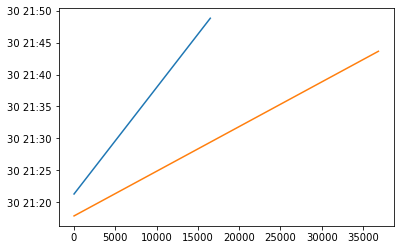

In [8]:
start = time.time()


## Just to illustrate that these two files correspond to the same times, let's plot their datetime arrays:
plot(NFEWdrone.t_arr_datetime)
plot(NFEWcorr.t_arr_datetime)

end = time.time()
print(end - start)
print(NFEWdrone.t_arr_datetime)
print(NFEWcorr.t_arr_datetime)

In [9]:
NFEWcorr.t

array([0.00000000e+00, 4.19430400e-02, 8.38860800e-02, ...,
       1.54606240e+03, 1.54610434e+03, 1.54614628e+03])

In [99]:
## OBJECTIVE 4: Initialize a concat class for a PULSED GRID FLIGHT

## Since we know the data are from the same time we can combine them with the Concat_Class:
## There are a few binary flags we should specify when we concat these inputs: (these are their default parameters)
    ## load_yaml=True       # This allows us to check for config files from previous analyses
    ## traceback=True       # Do we want print statements and verification plots to show?
    ## save_traceback=True  # This will allow us to save the verification plots!
## Specify directory parameter that allows you to specify where to look for previous config files:
    ## config_directory="/hirax/GBO_Analysis_Outputs/concat_config_files/"
## Specify directory parameter that allows you to specify where to save output plots and generate subdirectory:
    ## output_directory='/hirax/GBO_Analysis_Outputs/
    
## For this tutorial, I'm setting save_traceback to False, so we don't generate a bunch of duplicates
## Reading the traceback will show you what the script is doing and has lots of valuable information!
    ## If you are running this on rubin, you should have 5 saved parameters loaded from the config:
        ##  --> pulse_period = 400000.0
        ##  --> pulse_dutycycle = 200000.0
        ##  --> t_delta_pulse = -0.2136631146346346
        ##  --> t_delta_dji = -1.32000000000003
        ##  --> copolchan = 1.0
        
NFEWconcat=concat.CONCAT(CORRDATCLASS=NFEWcorr,DRONEDATCLASS=NFEWdrone,\
                             load_yaml=False,traceback=True,save_traceback=False, \
                       output_directory = '/home/am3674/JanFeb_2025_flights/', config_directory='/home/am3674/JanFeb_2025_flights/')

Initializing CONCAT CLASS with active traceback using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Traceback outputs will not be saved...
Concat initialized without previous config file...
Interpolating drone coordinates for each correlator timestamp:
  --> correlator timestamp axis contains 31954 elements
  --> drone timestamp axis contains 16503 elements


In [94]:
NFEWconcat_nopackage = CONCAT(CORRDATCLASS=NFEWcorr,DRONEDATCLASS=NFEWdrone,\
                             load_yaml=False,traceback=True,save_traceback=False, \
                       output_directory = '/home/am3674/JanFeb_2025_flights/', config_directory='/home/am3674/JanFeb_2025_flights/')

Initializing CONCAT CLASS with active traceback using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Traceback outputs will not be saved...
Concat initialized without previous config file...


<ipython-input-61-4e0cf3751658>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])


Interpolating drone coordinates for each correlator timestamp:
  --> correlator timestamp axis contains 31954 elements
  --> drone timestamp axis contains 16503 elements


<ipython-input-61-4e0cf3751658>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


In [14]:
Morgan_NFEWconcat = mc.CONCAT(CORRDATCLASS=NFEWcorr,DRONEDATCLASS=NFEWdrone,\
                             load_yaml=False,traceback=True,save_traceback=False, \
                       output_directory = '/home/am3674/JanFeb_2025_flights/', config_directory='/home/am3674/JanFeb_2025_flights/')

updated
Initializing CONCAT CLASS with active traceback using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Traceback outputs will not be saved...
Concat initialized without previous config file...
Interpolating drone coordinates for each correlator timestamp:
  --> correlator timestamp axis contains 31954 elements
  --> drone timestamp axis contains 16503 elements


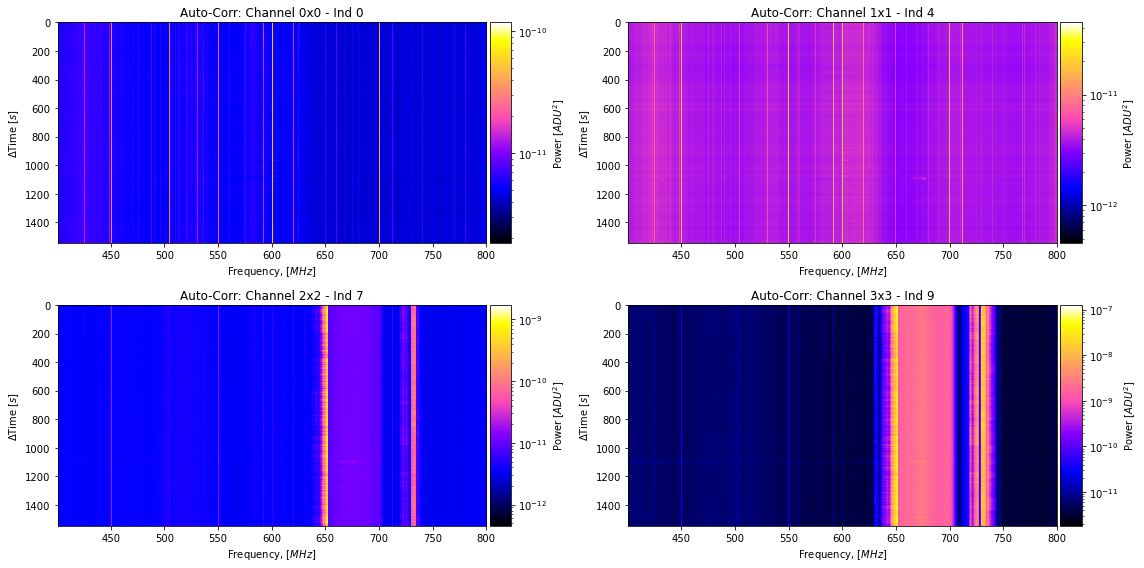

In [33]:
## What does our correlator data look like? We can consider a waterfall plot:
    ## If we see horizontal stripes, that means at some time, a lot of power was seen across all frequencies
    ## If we see vertical stripes, we know that some frequencies have more power than their neighbors for all time
    ## a grid flight should look like a series of horizontal stripes at regular intervals!
## Use plotting functions to produce a waterfall plot of the Concat_Class:
pu.Plot_Waterfalls(NFEWconcat_nopackage)

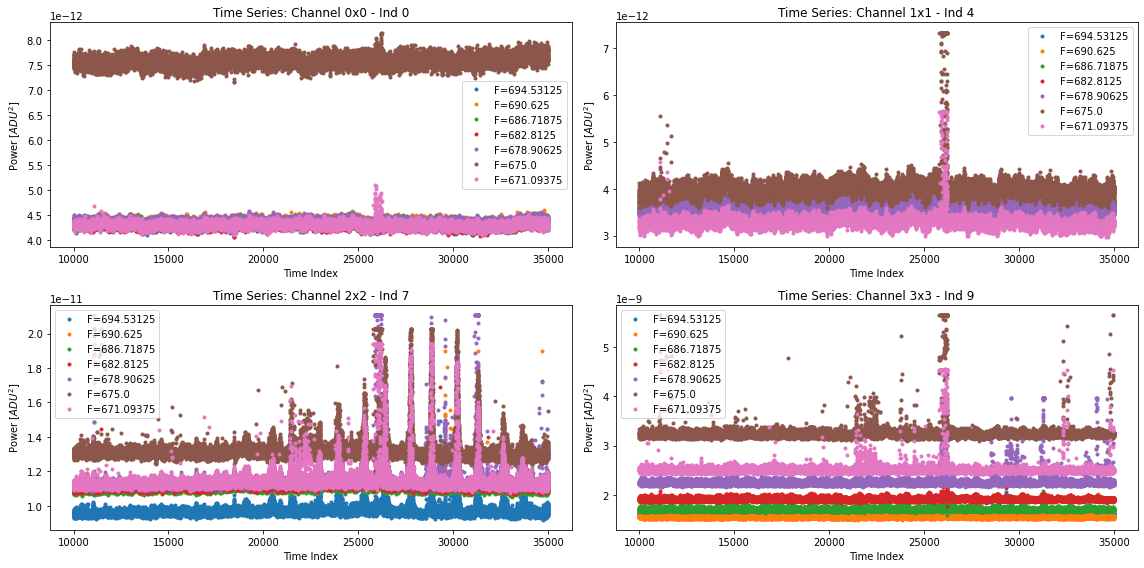

In [22]:
## What if we only want to look at a few frequencies and see a time series graph:
    ## The peaks are where the intensity is high, i.e. RFI events and when the drone is transiting...
    ## We can change the time and frequency indices to alter the contents of the graph...
## Use plotting functions to produce a time series plot of the Concat_Class, specify t and f bounds:
pu.Plot_Time_Series(Morgan_NFEWconcat,tbounds=[10000, 35000],freqlist=[270, 280, 290, 300, 310, 320, 330])

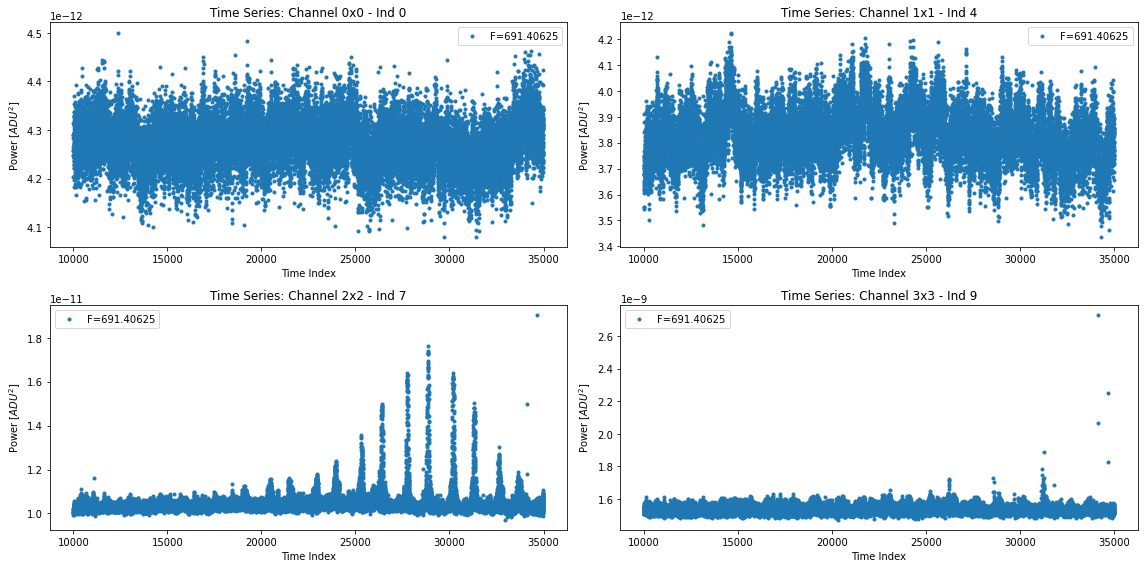

In [14]:
pu.Plot_Time_Series(Morgan_NFEWconcat,tbounds=[10000, 35000],freqlist=[278])

[0 1 2 3]
0
1


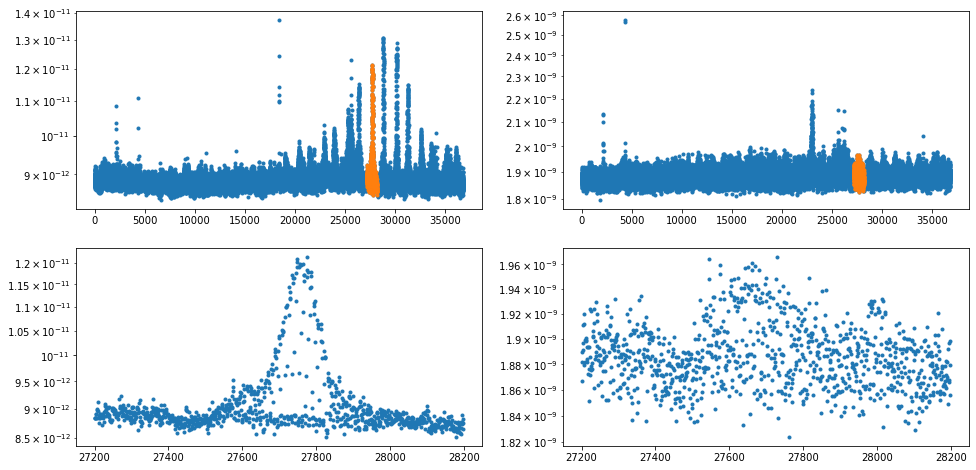

In [53]:
## Let's find the time bounds for a central transit, and examine those bounds when we solve for the source pulses:
tlb,tub=[27200, 28200]
find=260

fig=figure(figsize=(16,8))

print(NFEWconcat_nopackage.chmap)
other_indices = [2,3]
for i in range(NFEWconcat_nopackage.n_channels)[:2]:
    print(i)
    ax1=fig.add_subplot(2,2,i+1)
    ax2=fig.add_subplot(2,2,i+3)
    ax1.semilogy(NFEWconcat_nopackage.t_index[:],NFEWconcat_nopackage.V[:,find,NFEWconcat_nopackage.chmap[other_indices[i]]],'.')
    for ax in [ax1,ax2]:
        ax.semilogy(NFEWconcat_nopackage.t_index[tlb:tub],NFEWconcat_nopackage.V[tlb:tub,find,NFEWconcat_nopackage.chmap[other_indices[i]]],'.')

## So we've identified time bounds where we can see the pulsing source transit!
    ## Infact, I think we are seeing a sidelobe on channel 1!
    ## Let's see if we can extract the on/off indices...

ValueError: x and y arrays must be equal in length along interpolation axis.

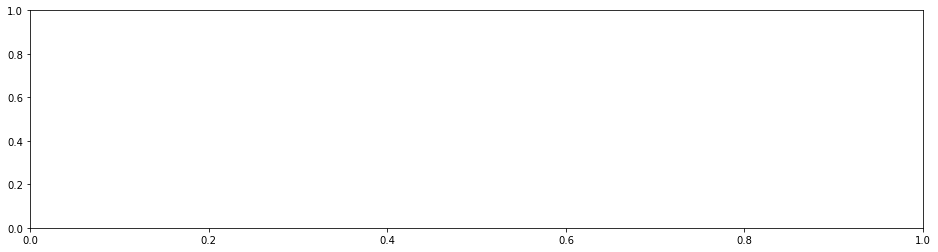

In [14]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.
NFEWconcat_nopackage.Extract_Source_Pulses(Period=0.4e6,Dutycycle=0.2e6, f_ind=[331], t_bounds=[27200,28200])


## Use the cell below for the correct pulsing information

Extracting Source Pulses using parameters loaded from config file:
  --> pulse_period = 400000.0
  --> pulse_dutycycle = 200000.0
  --> t_delta_pulse = -0.27999999999999986
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []


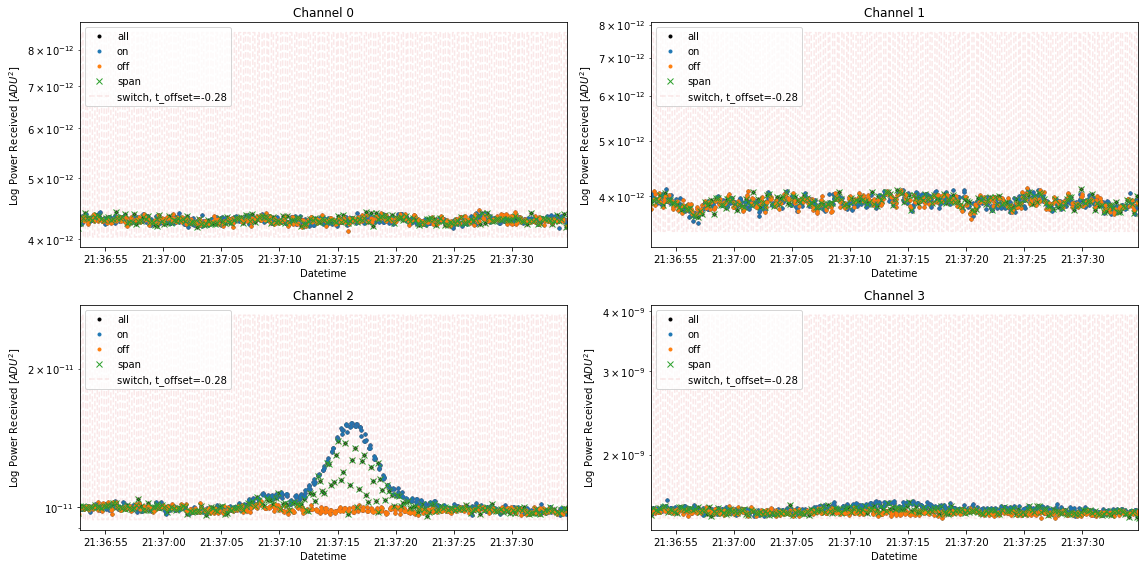

In [100]:
# using Morgan's input parameters for extract_source_pulses
# NFEWconcat.Extract_Source_Pulses(Period=0.9998e6,Dutycycle=0.5e6,t_bounds=[27200,28200],f_ind=331,minmaxpercents=[0.0001,100])

## this is the one that works!
NFEWconcat_nopackage.Extract_Source_Pulses(Period=0.4e6,Dutycycle=0.2e6,t_bounds=[27200,28200],f_ind=275,minmaxpercents=[10,100])

KeyboardInterrupt: 

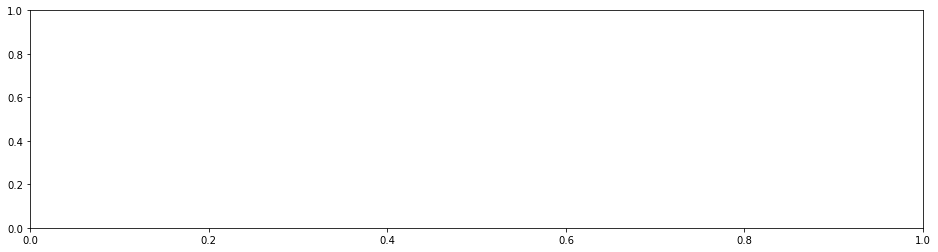

In [51]:
# extracting source pulses with Morgan's version of the concat function
Morgan_NFEWconcat.Extract_Source_Pulses(Period=0.4e6,Dutycycle=0.2e6,t_bounds=[27200,28200],f_ind=300,minmaxpercents=[10,100])

In [101]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
NFEWconcat_nopackage.Perform_Background_Subtraction(window_size=5)

Calculating background spectra from indices where the noise source is off.
  --> Background subtraction completed using window_size = 5


In [85]:
Morgan_NFEWconcat.Perform_Background_Subtraction(window_size=5)

Calculating background spectra from indices where the noise source is off.


AttributeError: 'CONCAT' object has no attribute 'inds_off'

In [12]:
pu.Plot_Time_Series(Morgan_NFEWconcat,tbounds=[10000, 35000],freqlist=[270, 280, 290, 300, 310])

NameError: name 'Morgan_NFEWconcat' is not defined

In [38]:
NFEWconcat_nopackage.__class__ = CONCAT

In [21]:
Morgan_NFEWconcat.__class__ = CONCAT

In [22]:
## OBJECTIVE 5C: concat Function: Synchronization_Function

## This function finds the absolute timing shift between the dji data from the drone and the correlator
    ## We will be loading t_delta_dji from the config file to save some time!
    ## This function only works if the source was pulsed and if V_bgsub was created using background subtraction.
    ## This function works by zooming into the gaussian main beam and removing saturated data points...
## To run, you must give the following:
    ## inputcorr  = the corr class used in the concat
    ## inputdrone = the drone class used in the concat
## The optional parameters and their default values are listed below:
    ## coarse_params=[-10.0,10.0,0.2]    = the min,max,step parameters for the coarse time offset array
    ## fine_params=[-0.5,0.5,0.01]       = the min,max,step parameters for the fine time offset array
    ## chans=np.arange(0,2)              = the channels to fit. 0,1 gives us each polarization -- need to change this to go from 0 to 3
    ## freqs=np.arange(100,1024,150)     = the min,max,step parameters for the freq array axis
    ## FMB_coordbounds=[50.0,50.0,150.0] = the cartesian coords we restrict around the main beam
        # x within +/- 50m from dish center in Local Cartesian (LC)
        # y within +/- 50m from dish center in Local Cartesian (LC)
        # z > 150m from dish center in Local Cartesian (LC)
    ## FMB_ampbound=0.999                = amplitude percentile threshold for saturation... 
        # time indices where the amplitude exceeds 0.999*maximum value are excluded because they are saturated
        
        
# try courseparams = [-5, 5]
# try fitting the raw data not inside of the synchronization function

# NFEWconcat_nopackage.Synchronization_Function(inputcorr=NFEWcorr,inputdrone=NFEWdrone,FMB_coordbounds=[20.0,20.0,20.0],FMB_ampbound=0.999,freqs=np.arange(300,330,20),chans=[2])
NFEWconcat_nopackage.Synchronization_Function(inputcorr=NFEWcorr,inputdrone=NFEWdrone,FMB_coordbounds=[10.0,10.0,20.0],FMB_ampbound=0.999,freqs=[275],chans=[2,3])

## Since we are loading from the config, we get to skip an iterative loop and just take the solution and apply it.
    ## The verification plot shown is hidden when traceback==False is set in the concat initialization
    ## Look closely at the verification plots to see which channel appears to be the co-pol (channel 1)
    ## In the bottom 2 panels, compare the fit result (white gaussian) to the data points (in color)
        ## We are omitting the saturated points to find the REAL max value, instead of squashing our peak
        ## If we are satisfied with this fit, we should try to save the parameters we found...

Synchronizing data from correlator and drone:
  --> Previous t_delta_dji not found
  --> Calculating via 2DGauss fitting routine:


<ipython-input-3-d7070a7ed17b>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])
<ipython-input-3-d7070a7ed17b>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


KeyboardInterrupt: 

Synchronizing data from correlator and drone:
  --> Loading parameter from existing configuration file: t_delta_dji = 0.2600000000000051
Applying a time correction of 0.26 seconds using Channel 0 fits.


<ipython-input-61-4e0cf3751658>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])
<ipython-input-61-4e0cf3751658>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


  --> Variable synchronation successful, generating output plots:
[2]


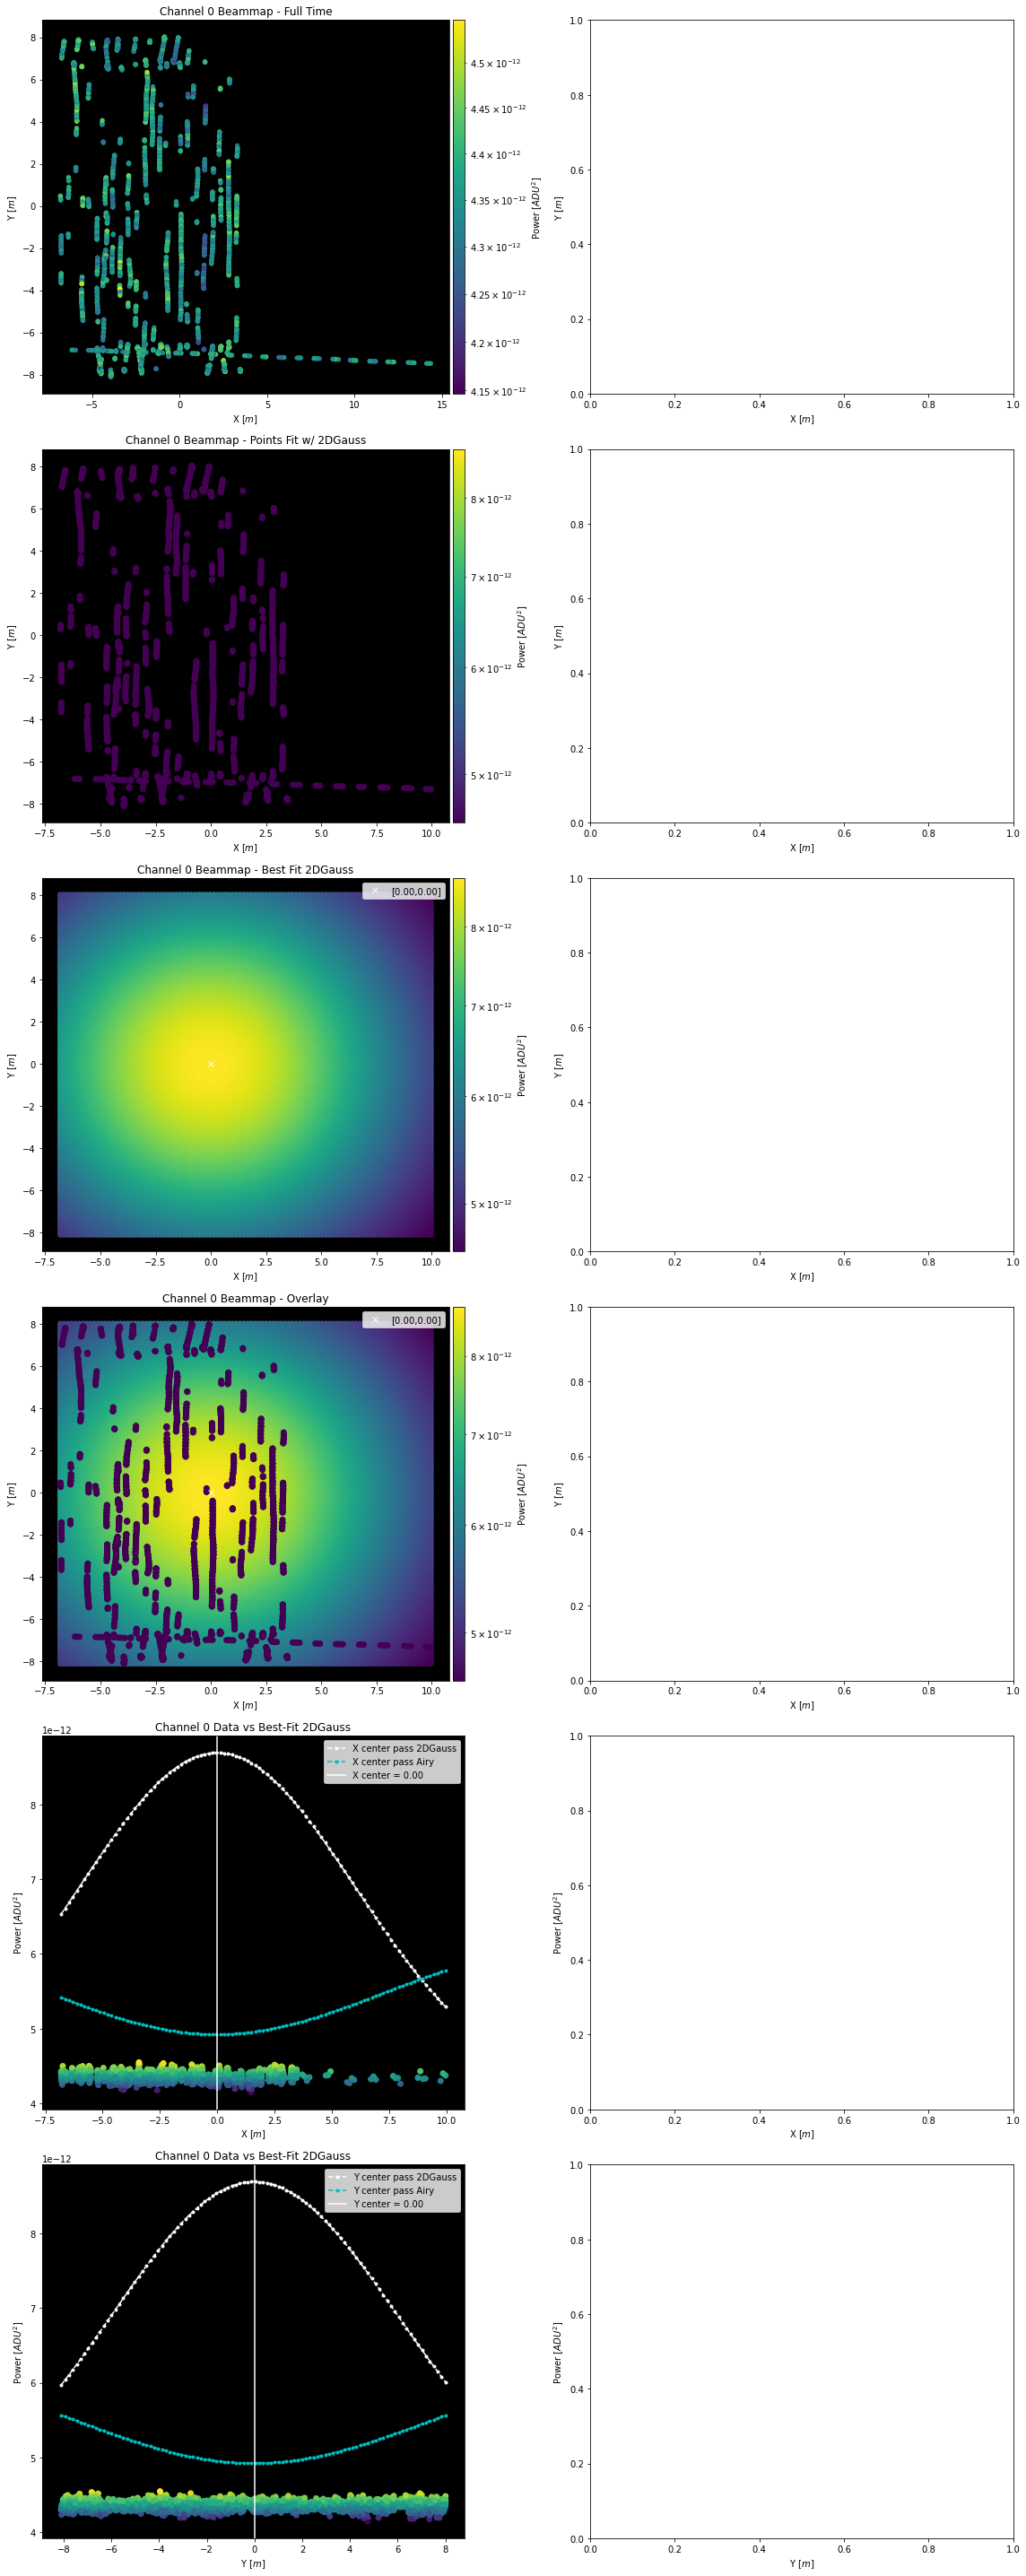

In [102]:
NFEWconcat_nopackage.Synchronization_Function(inputcorr=NFEWcorr,inputdrone=NFEWdrone,freqs=[270,280],\
                                    FMB_coordbounds=[10.0,10.0,10.0],FMB_ampbound=0.999,chans=[2], coarse_params=[-5.0,5.0,0.1])

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

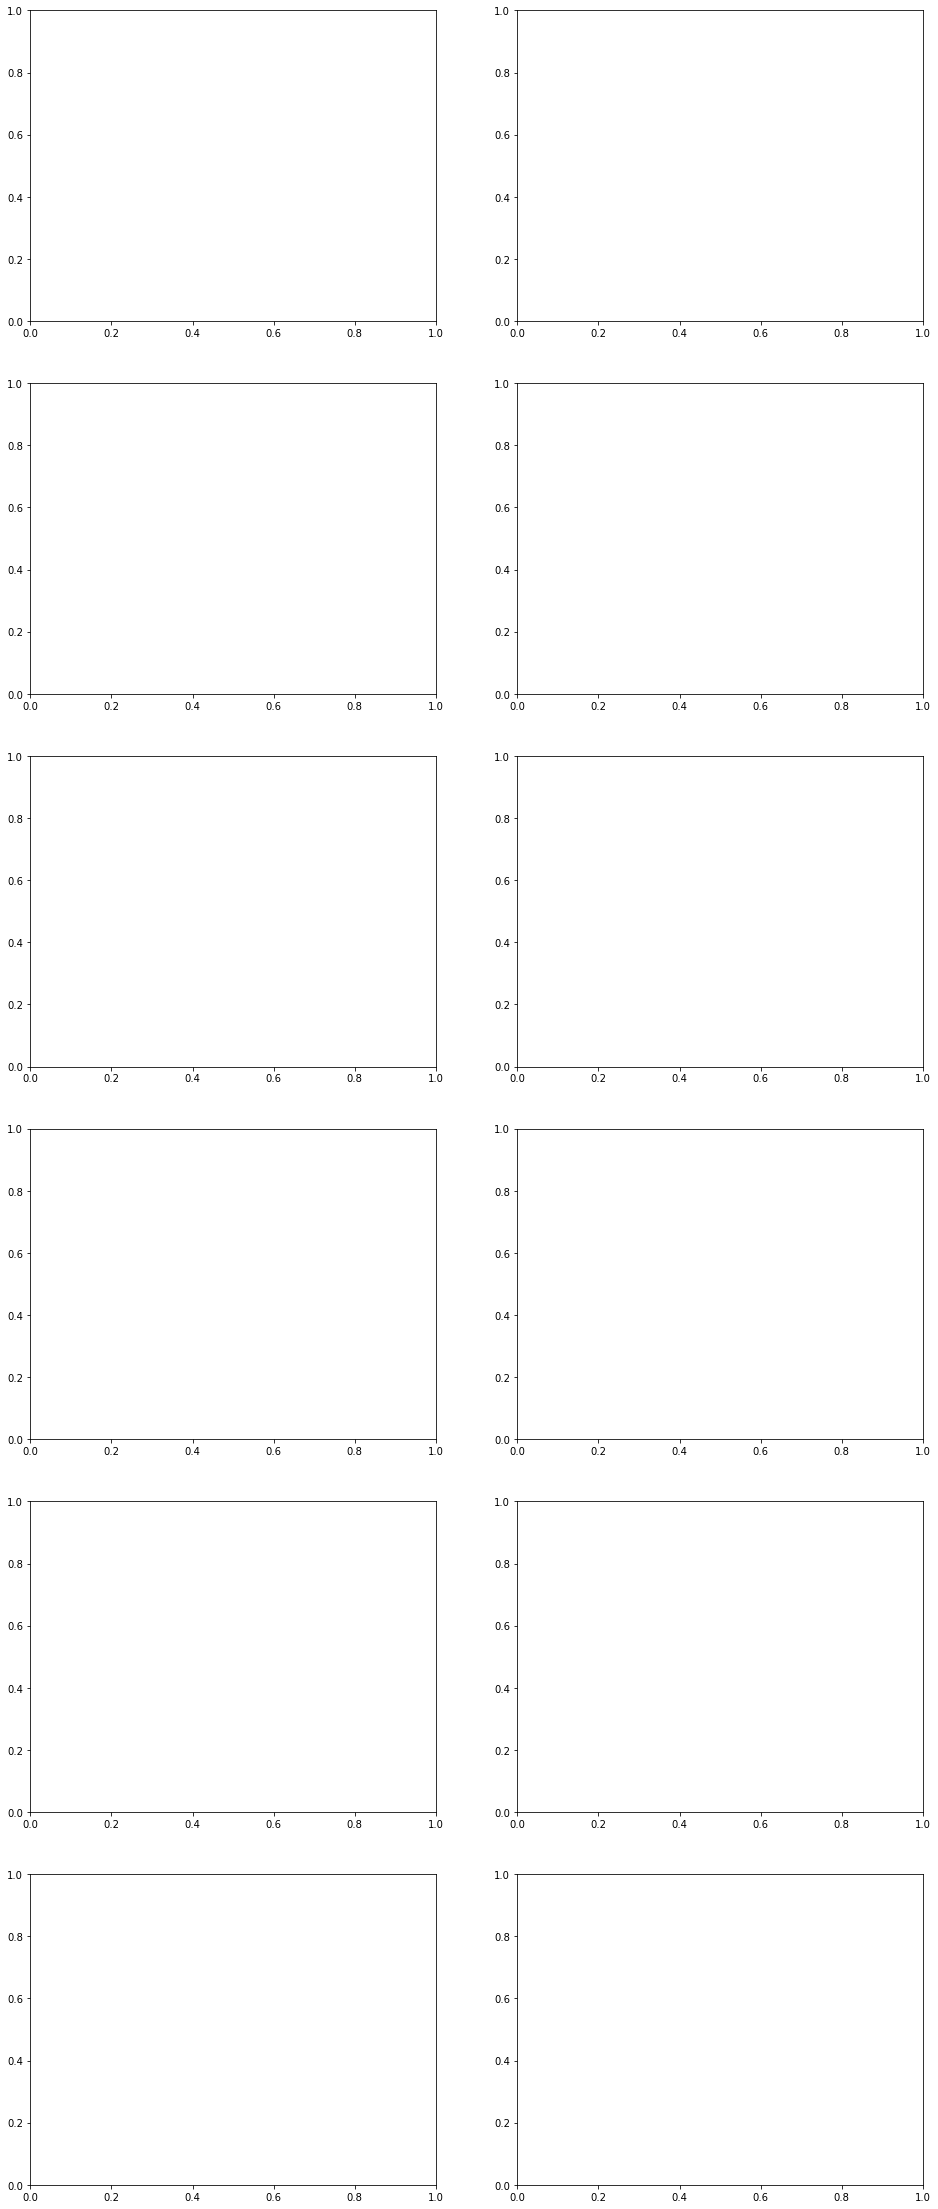

In [22]:
pu.Synchronization_Verification_Plots(inputconcat=NFEWconcat_nopackage,chans=[3,4],find=[300],coordbounds=[20.0,20.0,10.0],ampbound=0.999, coarse_params=[-20.0,20.0,0.2])

Synchronizing data from correlator and drone:
  --> Previous t_delta_dji not found
  --> Calculating via 2DGauss fitting routine:


/home/am3674/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


Applying a time correction of 8.41 seconds using Channel 0 fits.


IndexError: index 1 is out of bounds for axis 1 with size 1

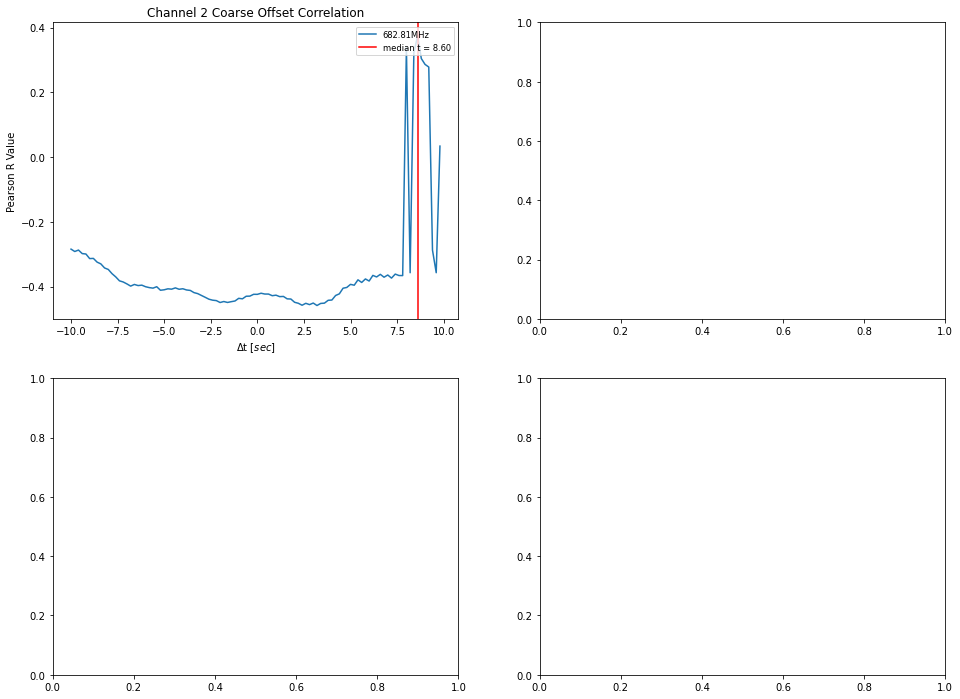

In [33]:
Morgan_NFEWconcat.Synchronization_Function(inputcorr=NFEWcorr,inputdrone=NFEWdrone,freqs=[300],\
                                    FMB_coordbounds=[20.0,20.0,10.0],FMB_ampbound=1,chans=[2])

In [20]:
import numpy as np
from matplotlib.pyplot import *
from scipy.optimize import least_squares
from astropy.modeling.models import AiryDisk2D
from scipy.stats import pearsonr

def Gauss(x,a,x0,sigma,k):
    return a*np.exp(-(x-x0)**2.0/(2.0*sigma**2.0))+k

def Airy_2d_LC_opt(P,x,y,V):
    AD=AiryDisk2D(1,5,5,radius=1)
    amp,x0,y0,rad,c=P
    return AD.evaluate(x,y,amp,x0,y0,rad)+c-V

def Airy_2d_LC_func(P,x,y):
    AD=AiryDisk2D(1,5,5,radius=1)
    amp,x0,y0,rad,c=P
    return AD.evaluate(x,y,amp,x0,y0,rad)+c

def Gauss_2d_LC_opt_wtheta(P,x,y,V):
    Gauss_eval = Gauss_2d_LC_func_wtheta(P,x,y)
    return Gauss_eval-V

def Gauss_2d_LC_func_wtheta(P,x,y):
    amp,x0,xsig,y0,ysig,c,theta=P
    A=(0.5*(((np.cos(theta)/xsig)**2.0)+((np.sin(theta)/ysig)**2.0)))
    B=(0.25*((np.sin(2.0*theta)/(ysig**2.0))-(np.sin(2.0*theta)/(xsig**2.0))))
    C=(0.5*(((np.sin(theta)/xsig)**2.0)+((np.cos(theta)/ysig)**2.0))) 
    return amp*np.exp(-1.0*((A*((x-x0)**2.0))+(2.0*B*(x-x0)*(y-y0))+(C*((y-y0)**2.0))))+c

def Gauss_2d_LC_opt(P,x,y,V):
    Gauss_eval = Gauss_2d_LC_func(P,x,y)
    return Gauss_eval-V

def Gauss_2d_LC_func(P,x,y):
    amp,x0,xsig,y0,ysig,c=P
    xx = ((x-x0)**2)/(2*(xsig**2))
    yy = ((y-y0)**2)/(2*(ysig**2))
    return amp*np.exp(-1.0*(xx + yy))+c

def Fit_Main_Beam(inputconcat,chans,freqs,theta_solve,coordbounds=[50.0,50.0,150.0],ampbound=0.999,Vargs='None'):
    A_popt=np.zeros((len(chans),len(freqs),5))
    A_PR=np.zeros((len(chans),len(freqs)))
    G_popt=np.zeros((len(chans),len(freqs),7))
    G_PR=np.zeros((len(chans),len(freqs)))
    ## define timecuts for cartesian coordinates:
    txcut=inputconcat.t_index[np.abs(inputconcat.drone_xyz_LC_interp[:,0])<coordbounds[0]]
#     print(txcut)
    tycut=inputconcat.t_index[np.abs(inputconcat.drone_xyz_LC_interp[:,1])<coordbounds[1]]
#     print(tycut)
    tzcut=inputconcat.t_index[np.abs(inputconcat.drone_xyz_LC_interp[:,2])>coordbounds[2]]
#     print(tzcut)
    coordcut=np.intersect1d(np.intersect1d(txcut,tycut),tzcut)
#     print(coordcut)
    for i,chan in enumerate(chans):
        for j,find in enumerate(freqs):
            try:
                ## apply amplitude cut:
                if Vargs=='None':
                    tacut=inputconcat.t_index[inputconcat.V[:,find,chan]<ampbound*(np.nanmax(inputconcat.V[:,find,chan]))]
#                     print(tacut)
#                     print(np.count_nonzero(np.isnan(tacut)))
                elif Vargs=='bgsub':
                    tacut=inputconcat.t_index[inputconcat.V_bgsub[:,find,chan]<ampbound*(np.nanmax(inputconcat.V_bgsub[:,find,chan]))]
#                     print(tacut)
#                     print(np.count_nonzero(np.isnan(tacut)))
                else:
                    tacut=inputconcat.t_index[inputconcat.V[:,find,chan]<ampbound*(np.nanmax(inputconcat.V[:,find,chan]))]
                try:
                    ttcut=np.intersect1d(np.intersect1d(coordcut,tacut),inputconcat.inds_on)
#                     print(ttcut)
#                     print(np.count_nonzero(np.isnan(ttcut)))
                except AttributeError:
                    ttcut=np.intersect1d(coordcut,tacut)                    
                ## pull the proper coords for fitting:
                mbx=inputconcat.drone_xyz_LC_interp[ttcut,0]
                mby=inputconcat.drone_xyz_LC_interp[ttcut,1]
                mbz=inputconcat.drone_xyz_LC_interp[ttcut,2]
                if Vargs=='None':
                    mbV=inputconcat.V[ttcut,find,chan]
                elif Vargs=='bgsub':
                    mbV=inputconcat.V_bgsub[ttcut,find,chan]
                else:
                    mbV=inputconcat.V[ttcut,find,chan]
                mb_input_data=np.array([mbx,mby,mbV])
                ## shared params:
                amp0=np.nanmax(mbV)
                bg0=np.nanmin(mbV)
#                 print(inputconcat.dish_coords.shape)
#                 print(chan)
                x00=inputconcat.dish_coords[chan,0]
                y00=inputconcat.dish_coords[chan,1]
                ## airy params:
                rad0=25.0
                ## 2dgauss params:
                xsig0=10.0
                ysig0=10.0
                theta0=0.0

                if theta_solve: # if this is true, solve for theta
                    ## initial guess and bounds:
                    pA=np.array([amp0,x00,y00,rad0,bg0])
                    pG=np.array([amp0,x00,xsig0,y00,ysig0,bg0,theta0])
                    bnds = ((-np.inf, -np.inf,0, -np.inf,0, -np.pi,-np.inf/4),
                        (np.inf, np.inf,np.inf, np.inf,np.inf, np.pi,np.inf/4))
                    ## run the fits:
                    G_popt[i,j]=least_squares(Gauss_2d_LC_opt_wtheta,x0=pG,bounds=bnds,method='trf',args=mb_input_data).x
                    G_PR[i,j]=pearsonr(mbV,Gauss_2d_LC_func_wtheta(G_popt[i,j],mbx,mby))[0]
                else: # default: don't solve for theta
                    pA=np.array([amp0,x00,y00,rad0,bg0])
                    pG=np.array([amp0,x00,xsig0,y00,ysig0,bg0])
                    ## run the fits:
                    G_popt[i,j,0:6]=least_squares(Gauss_2d_LC_opt,x0=pG,method='trf',args=mb_input_data).x
                    G_PR[i,j]=pearsonr(mbV,Gauss_2d_LC_func(G_popt[i,j,0:6],mbx,mby))[0]

                A_popt[i,j]=least_squares(Airy_2d_LC_opt,x0=pA,args=mb_input_data).x
                A_PR[i,j]=pearsonr(mbV,Airy_2d_LC_func(A_popt[i,j,:],mbx,mby))[0]
            except ValueError:
                A_popt[i,j,:]=np.nan*np.zeros(5)
                A_PR[i,j]=np.nan
                G_popt[i,j,:]=np.nan*np.zeros(7)
                G_PR[i,j]=np.nan
    return A_popt,A_PR,G_popt,G_PR

In [38]:
# testing out the fitting function
Fit_Main_Beam(NFEWconcat_nopackage,chans=[0, 1, 2, 3],freqs=[301],theta_solve=False,ampbound=0.999,coordbounds=[20,20,10])


NameError: name 'Fit_Main_Beam' is not defined

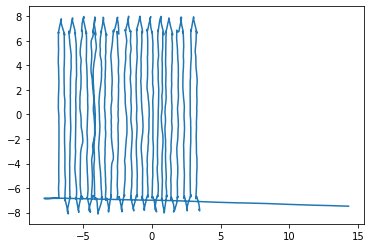

In [92]:
plot(Morgan_NFEWconcat.drone_xyz_LC_interp[:,0], Morgan_NFEWconcat.drone_xyz_LC_interp[:,1])

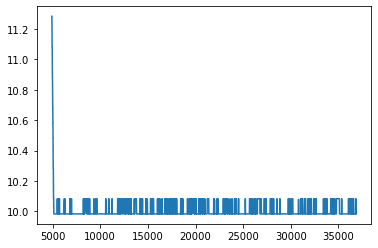

In [99]:
plot(Morgan_NFEWconcat.drone_xyz_LC_interp[:,2])

In [ ]:
## OBJECTIVE 5D: concat Function: Export_yaml

## When we have results we want to save, we should export our results to a config file for future use:
    ## The file will be written to the directory stated when the concat class was initialized.
    ## If a concat config yaml file already exists, a new version will be saved.
## Uncomment this if you want to export a config file... 
#concattest0825.Export_yaml()

In [ ]:
## OBJECTIVE 5E: concat Function: Main_Beam_Fitting

## Now we can do some analysis, since we have synchronized useful data. We can begin by fitting the main beam:
    ## You can specify the directory where you want the fit params to be output:
    ## fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/'
    ## This one sometimes takes a while, feel free to get a coffee or something.
concattest0825.Main_Beam_Fitting()

In [ ]:
## Now we can examine the Gaussian results, if we so choose:
    #print channel 1, freq 900, all gauss params: [amp0,x00,xsig0,y00,ysig0,theta0,bg0]
print(concattest0825.G_popt[1,900,:])

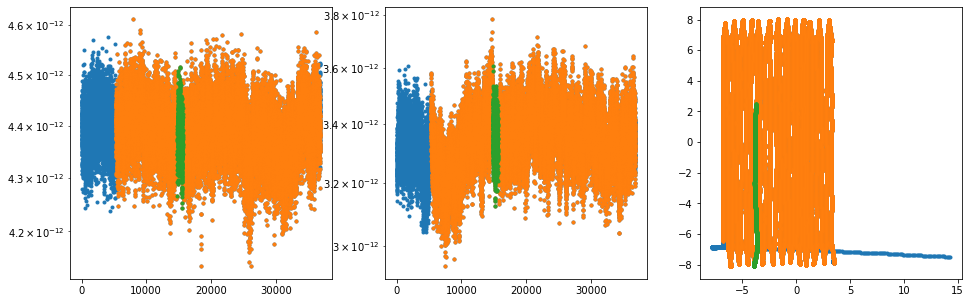

In [66]:
## Let's make a nice beammap using the data we just analyzed:
    ## First lets find time index bounds that select only the nice grid passes, no extra stuff: [6900,28300]
    ## These points appear as orange, and show just the grid in graph 3:
fig1,[ax1,ax2,ax3]=subplots(nrows=1,ncols=3,figsize=(16,5))
tlb,tub=[0,-1]
ax1.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,0],'.')
ax2.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,1],'.')
ax3.plot(Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,0],Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,1],'.')
tlb,tub=[5300,36800]
ax1.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,0],'.')
ax2.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,1],'.')
ax3.plot(Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,0],Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,1],'.')
tlb,tub=[14800,15600]
ax1.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,0],'.')
ax2.semilogy(Morgan_NFEWconcat.t_index[tlb:tub],Morgan_NFEWconcat.V[tlb:tub,400,1],'.')
ax3.plot(Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,0],Morgan_NFEWconcat.drone_xyz_LC_interp[tlb:tub,1],'.')

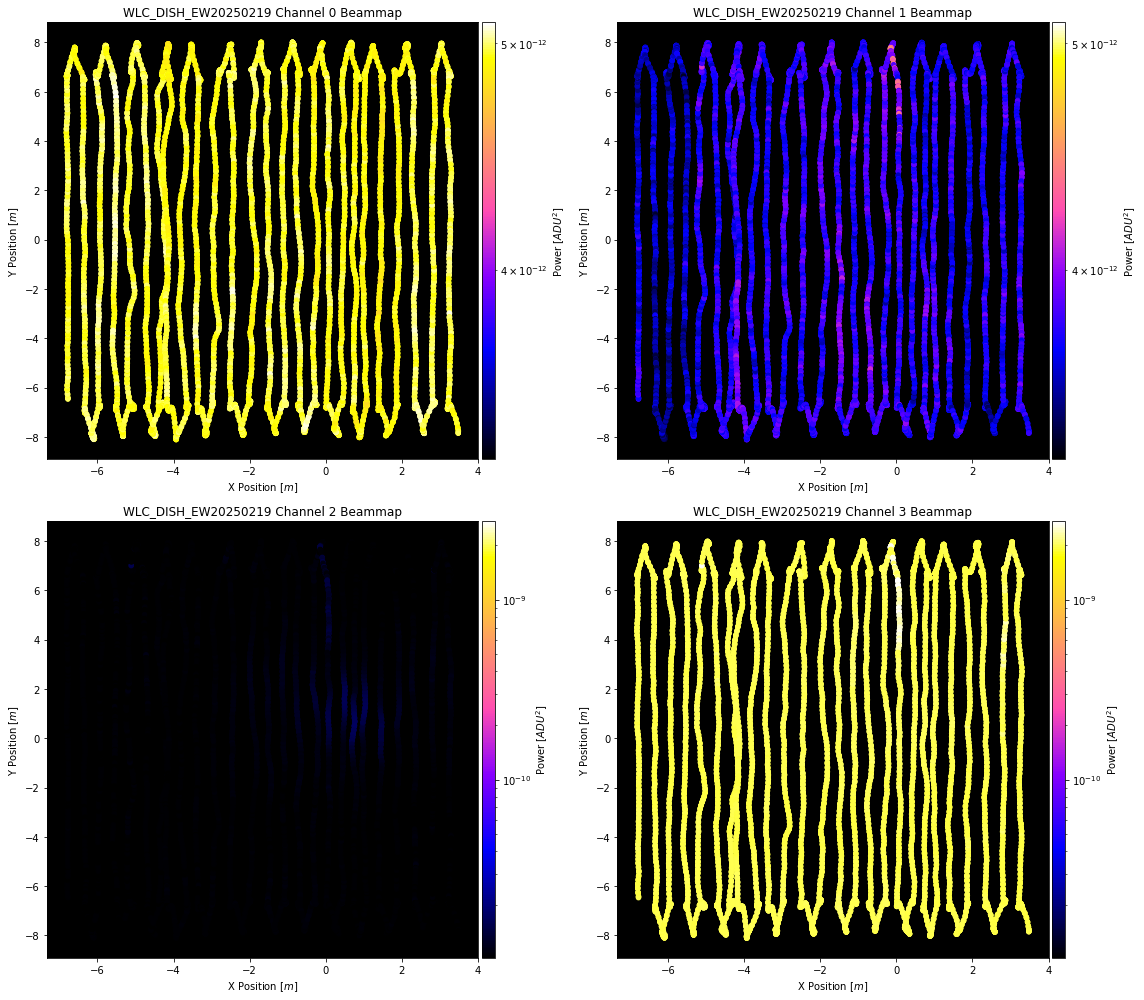

In [103]:
## Now we can execute the Plot_Beammap function from plotting_utils.py:
    ## We should use the t_bounds we just found [6900,28300] to restrict to a nice grid
    ## We can choose coord_args to see if we want cartesian or polar: {"LC","Pol"}
    ## We can choose pulse_args to see what correlator data we want: {None,"on","off","bg","bgsub"}
    
## First lets see the source on indices in cartesian:
pu.Plot_Beammap(NFEWconcat_nopackage,coord_args='LC',pulse_args="on",\
                t_bounds=[5300,36800],f_bounds=[250,360],cbounds=[],dotsize=20)

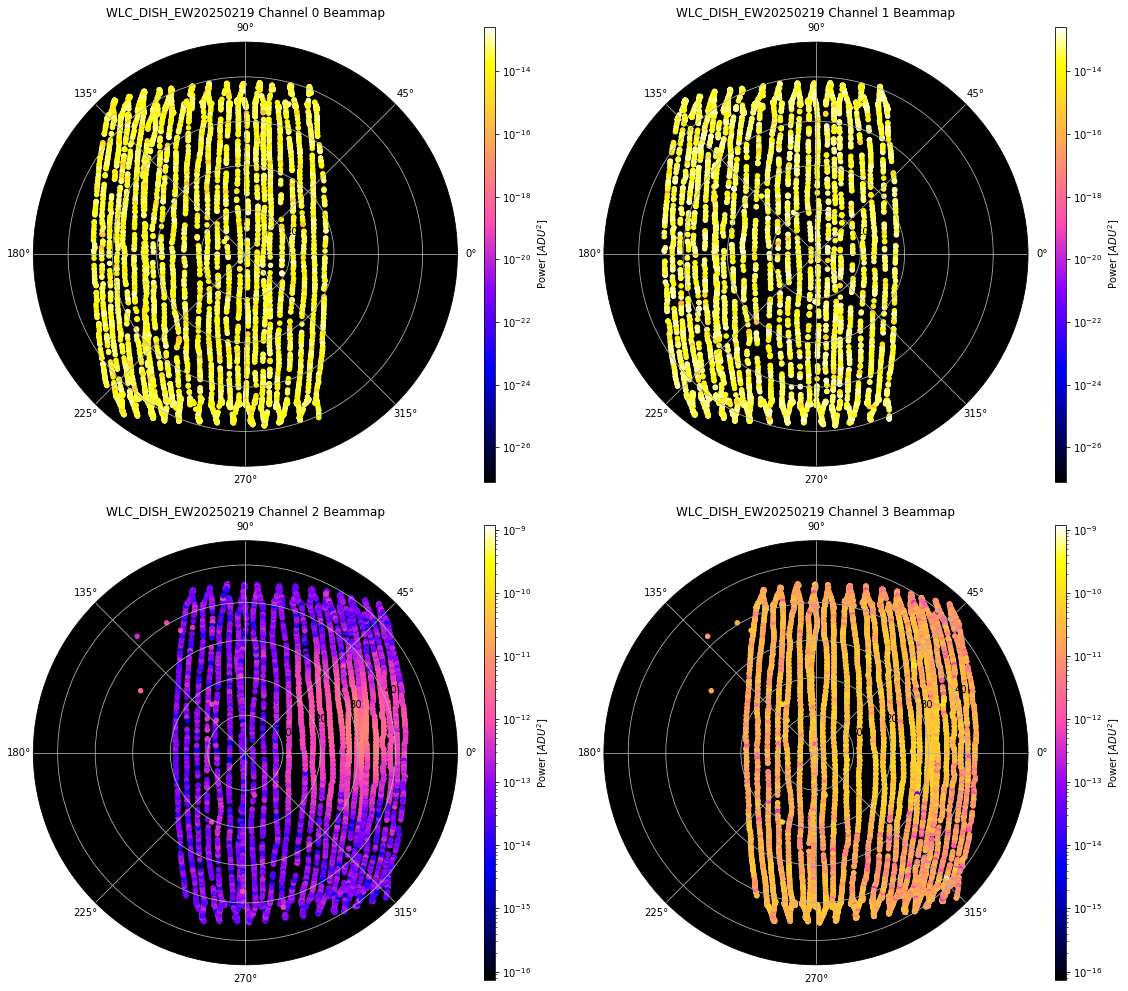

In [104]:
## We can also look at, for instance, the Polar background subtracted beammap:
pu.Plot_Beammap(NFEWconcat_nopackage,coord_args='Pol',pulse_args='bgsub',\
                t_bounds=[5300,36800],f_bounds=[278, 279],cbounds=[],dotsize=20)

In [105]:
dx=NFEWconcat_nopackage.drone_xyz_LC_interp[:,0]
dy=NFEWconcat_nopackage.drone_xyz_LC_interp[:,1]
dcoords=NFEWconcat_nopackage.drone_xyz_LC_interp[:,:]
find=278
wl=(3.0e8/(NFEWconcat_nopackage.freq[find]/1e-6))
dc=(NFEWconcat_nopackage.V_cross_bgsub[:,find])
dcabs=np.abs(NFEWconcat_nopackage.V_cross_bgsub[:,find])
dcang=np.angle(NFEWconcat_nopackage.V_cross_bgsub[:,find])[:,0]
dcang[dcang<0]+=2*np.pi

In [106]:
NFEWconcat_nopackage.V_cross[NFEWconcat_nopackage.inds_on]

array([[[-9.09494702e-13+0.00000000e+00j],
        [ 1.53805153e-12+9.70140790e-13j],
        [ 8.29941161e-13-8.31034628e-14j],
        ...,
        [ 8.03063996e-13+2.25679064e-14j],
        [ 7.59656442e-13-4.25945372e-14j],
        [ 7.85704391e-13-3.88457008e-14j]],

       [[-9.09494702e-13+0.00000000e+00j],
        [ 1.34440786e-12+9.78791838e-13j],
        [ 7.65317284e-13-7.23874900e-14j],
        ...,
        [ 7.32369349e-13-5.75073761e-14j],
        [ 7.59333267e-13-2.77284620e-14j],
        [ 7.56553957e-13-3.01845961e-14j]],

       [[-9.09494702e-13+0.00000000e+00j],
        [ 1.40645073e-12+1.02903783e-12j],
        [ 7.99488116e-13-8.24473828e-14j],
        ...,
        [ 8.43101637e-13+4.07173975e-14j],
        [ 8.19767094e-13+1.13111442e-14j],
        [ 8.37412479e-13+3.89749710e-14j]],

       ...,

       [[-9.09494702e-13+0.00000000e+00j],
        [ 1.39273139e-12+9.91462565e-13j],
        [ 7.51375585e-13-9.98881753e-14j],
        ...,
        [ 8.58260201e-13-1

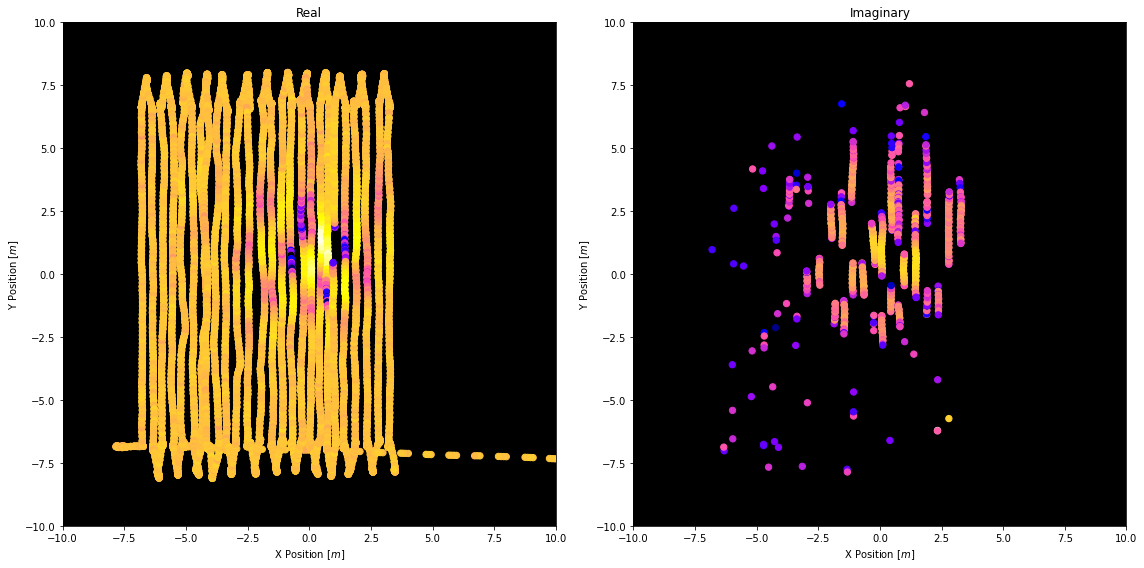

In [107]:
fig1,[ax1,ax2]=subplots(nrows=1,ncols=2,figsize=(16,8))
im1=ax1.scatter(dx[NFEWconcat_nopackage.inds_on],dy[NFEWconcat_nopackage.inds_on],s=40,c=np.real(NFEWconcat_nopackage.V_cross[NFEWconcat_nopackage.inds_on,find]),cmap='gnuplot2',norm=LogNorm())
im2=ax2.scatter(dx[NFEWconcat_nopackage.inds_on],dy[NFEWconcat_nopackage.inds_on],s=40,c=np.imag(NFEWconcat_nopackage.V_cross[NFEWconcat_nopackage.inds_on,find]),cmap='gnuplot2',norm=LogNorm())
titles=['Real','Imaginary']
cbars=['Power [$ADU^2$]','Power [$ADU^2$]']
images=[im1,im2]
for i,ax in enumerate([ax1,ax2]):
    ax.set_xlim(-10,10)
    ax.set_ylim(-10,10)
    ax.set_facecolor("k")
    ax.set_xlabel('X Position $[m]$')
    ax.set_ylabel('Y Position $[m]$')
    divider=make_axes_locatable(ax)
#     cax=divider.append_axes("right", size="3%", pad=0.05)
#     cbar=fig1.colorbar(images[i],cax=cax)
#     cbar.set_label(cbars[i])
    ax.set_title(titles[i])
tight_layout()

In [73]:
tx=np.intersect1d(NFEWconcat_nopackage.t_index[-10<dx],NFEWconcat_nopackage.t_index[10>dx])
ty=np.intersect1d(NFEWconcat_nopackage.t_index[-10<dy],NFEWconcat_nopackage.t_index[10>dy])

tcut=np.intersect1d(np.intersect1d(tx,ty),NFEWconcat_nopackage.inds_on)

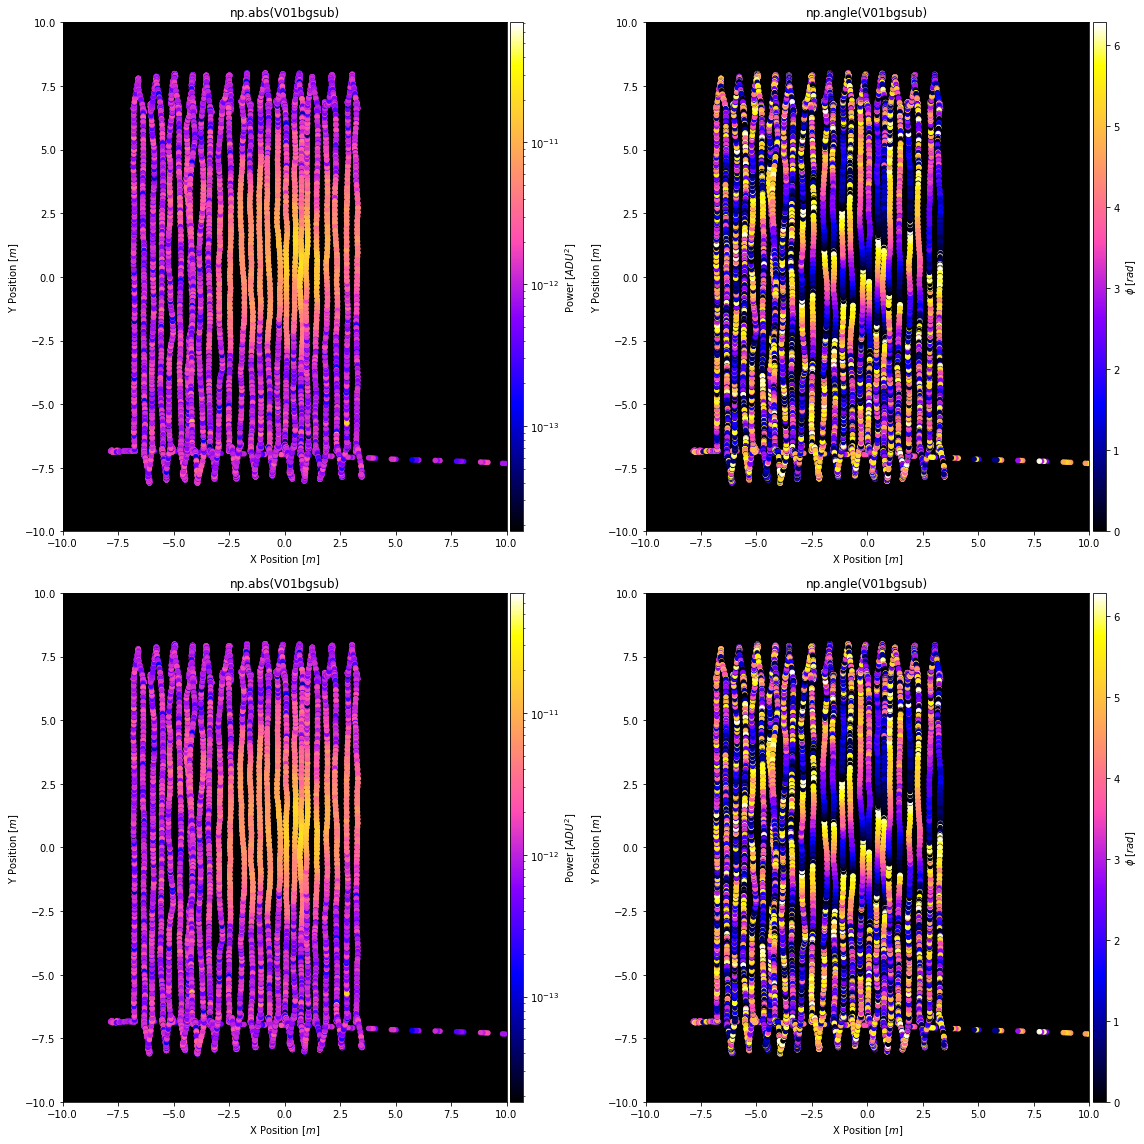

In [74]:
fig1,[[ax1,ax2],[ax3,ax4]]=subplots(nrows=2,ncols=2,figsize=(16,16))
# tcut=[5300,36800]

im1=ax1.scatter(dx[NFEWconcat_nopackage.inds_on],dy[NFEWconcat_nopackage.inds_on],s=20,c=dcabs[NFEWconcat_nopackage.inds_on],cmap='gnuplot2',norm=LogNorm())
im2=ax2.scatter(dx[NFEWconcat_nopackage.inds_on],dy[NFEWconcat_nopackage.inds_on],s=20,c=dcang[NFEWconcat_nopackage.inds_on],cmap='gnuplot2')
im3=ax3.scatter(dx[tcut],dy[tcut],s=20,c=dcabs[tcut],cmap='gnuplot2',norm=LogNorm())
im4=ax4.scatter(dx[tcut],dy[tcut],s=20,c=dcang[tcut],cmap='gnuplot2')
images=[im1,im2,im3,im4]
titles=["np.abs(V01bgsub)","np.angle(V01bgsub)","np.abs(V01bgsub)","np.angle(V01bgsub)"]
cbars=['Power [$ADU^2$]','$\phi$ [$rad$]','Power [$ADU^2$]','$\phi$ [$rad$]']
for i,ax in enumerate([ax1,ax2,ax3,ax4]):
    ax.set_xlim(-10,10)
    ax.set_ylim(-10,10)
    ax.set_facecolor("k")
    ax.set_xlabel('X Position $[m]$')
    ax.set_ylabel('Y Position $[m]$')
    divider=make_axes_locatable(ax)
    cax=divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig1.colorbar(images[i],cax=cax)
    cbar.set_label(cbars[i])
    ax.set_title(titles[i])
tight_layout()

In [108]:
def Plot_Complex_Maps(concat,find,data='bgsub',tcut=None, size=40):
    
    dx=concat.drone_xyz_LC_interp[:,0]
    dy=concat.drone_xyz_LC_interp[:,1]
    
    fig1,axes=subplots(nrows=2,ncols=2,figsize=(15,15))
    axes=axes.flatten()
    
    if data=='data':
        if tcut==None:
            tcut=concat.inds_on
        
        im1=axes[0].scatter(dx[tcut],dy[tcut],s=size,c=np.real(concat.V_cross[tcut,find]),cmap='plasma',norm=LogNorm())
        im2=axes[1].scatter(dx[tcut],dy[tcut],s=size,c=np.imag(concat.V_cross[tcut,find]),cmap='plasma')
        im3=axes[2].scatter(dx[tcut],dy[tcut],s=size,c=np.abs(concat.V_cross[tcut,find]),cmap='plasma',norm=LogNorm())
        im4=axes[3].scatter(dx[tcut],dy[tcut],s=size,c=np.angle(concat.V_cross[tcut,find])[:,0],cmap='plasma')
        titles=['Data: Real','Data: Imaginary','Data: Amplitude','Data: Phase']
        
    if data=='bg':
        
        if tcut==None:
            tcut=concat.inds_off
            
        im1=axes[0].scatter(dx[tcut],dy[tcut],s=size,c=np.real(concat.V_cross_bg[tcut,find]),cmap='plasma',norm=LogNorm())
        im2=axes[1].scatter(dx[tcut],dy[tcut],s=size,c=np.imag(concat.V_cross_bg[tcut,find]),cmap='plasma')
        im3=axes[2].scatter(dx[tcut],dy[tcut],s=size,c=np.abs(concat.V_cross[tcut,find]),cmap='plasma',norm=LogNorm())
        im4=axes[3].scatter(dx[tcut],dy[tcut],s=size,c=np.angle(concat.V_cross[tcut,find])[:,0],cmap='plasma')
        titles=['Background: Real','Background: Imaginary','Background: Amplitude','Background: Phase']
    
    if data=='bgsub':
        
        if tcut==None:
            tcut=concat.inds_on
            
        im1=axes[0].scatter(dx[tcut],dy[tcut],s=size,c=np.real(concat.V_cross_bgsub[tcut,find]),cmap='plasma',norm=LogNorm())
        im2=axes[1].scatter(dx[tcut],dy[tcut],s=size,c=np.imag(concat.V_cross_bgsub[tcut,find]),cmap='plasma')
        im3=axes[2].scatter(dx[tcut],dy[tcut],s=size,c=np.abs(concat.V_cross_bgsub[tcut,find]),cmap='plasma',norm=LogNorm())
        im4=axes[3].scatter(dx[tcut],dy[tcut],s=size,c=np.angle(concat.V_cross_bgsub[tcut,find])[:,0],cmap='plasma')
        titles=['Background-Subtracted: Real','Background-Subtracted: Imaginary','Background-Subtracted: Amplitude','Background-Subtracted: Phase']


    cbars=['Power [$ADU^2$]','Power [$ADU^2$]','Power [$ADU^2$]','Phase (radians)']
    images=[im1,im2,im3,im4]
    for i,ax in enumerate(axes):
        ax.set_xlim(-10,10)
        ax.set_ylim(-10,10)
        ax.set_facecolor("k")
        ax.set_xlabel('X Position $[m]$')
        ax.set_ylabel('Y Position $[m]$')
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="3%", pad=0.05)
        cbar=fig1.colorbar(images[i],cax=cax)
        cbar.set_label(cbars[i])
        ax.set_title(titles[i])
        ax.set_aspect('equal')
    tight_layout()

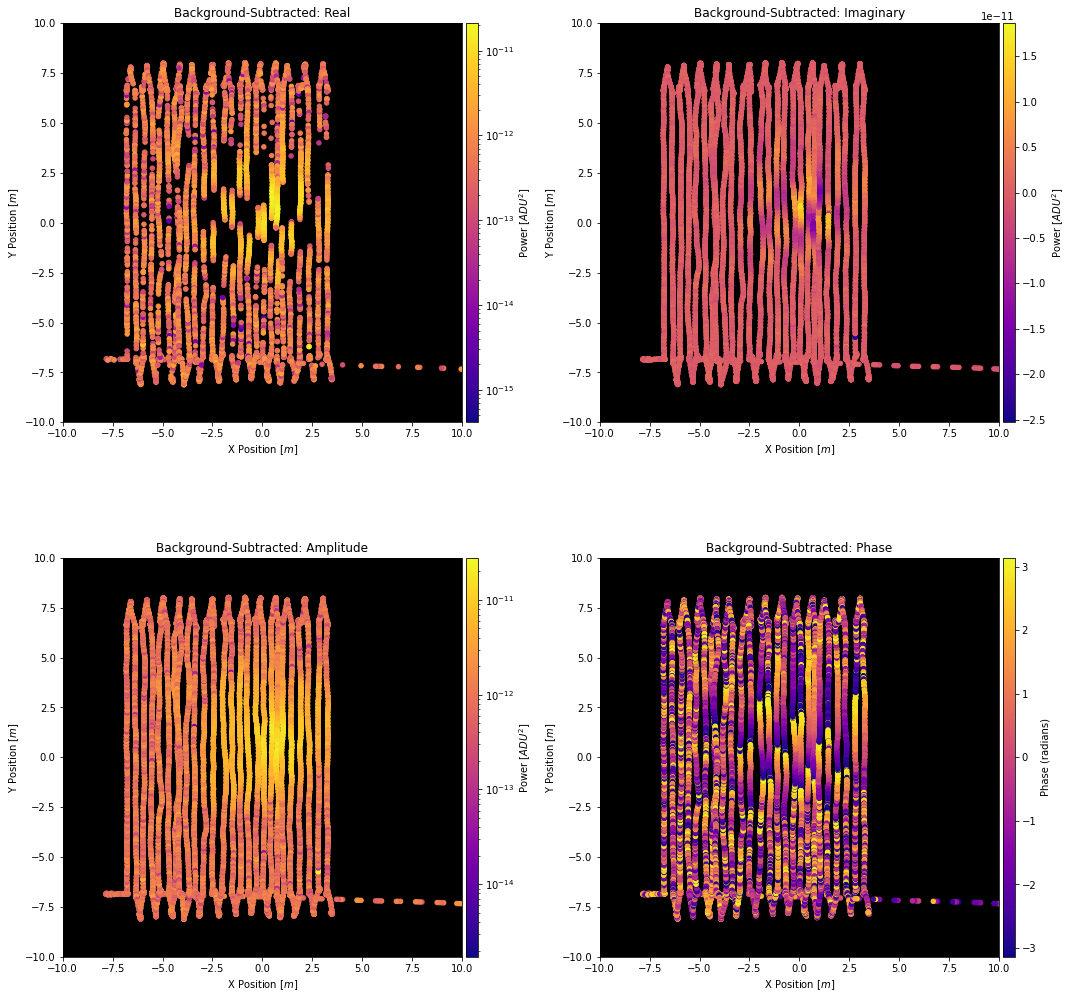

In [109]:
Plot_Complex_Maps(NFEWconcat_nopackage, 275, size=20, data='bgsub')

In [ ]:
plot(concattest0825.drone_xyz_LC_interp[6920:7800,0],concattest0825.drone_xyz_LC_interp[6920:7800,1])
plot(concattest0825.drone_xyz_LC_interp[7900:8200,0],concattest0825.drone_xyz_LC_interp[7900:8200,1])
dx=(concattest0825.drone_xyz_LC_interp[8200,0]-concattest0825.drone_xyz_LC_interp[7900,0])
dt=((concattest0825.t_arr_datetime[8200]-concattest0825.t_arr_datetime[7900]).total_seconds())

print("for a sample data set of {} time indices...".format(str(300)))
print("--> the timestep is are {} sec".format(concattest0825.tstep))
print("--> the total duration is  {} sec".format(dt))
print("--> the distance travelled is {} m".format(dx))
print("--> the angular distance travelled is {} deg".format(180/np.pi*np.arctan(dx/np.nanmean(concattest0825.drone_xyz_LC_interp[7900:8200,2]))))
print("--> the average velocity is {} m/s".format(dx/dt))
print("--> the angular velocity is {} deg/s".format(180/np.pi*np.arctan(dx/np.nanmean(concattest0825.drone_xyz_LC_interp[7900:8200,2]))/dt))
print("--> the angular step size (per time index) is {} deg".format(180/np.pi*np.arctan(dx/np.nanmean(concattest0825.drone_xyz_LC_interp[7900:8200,2]))/300))


In [ ]:
## Plot for Maile:
fig,ax1=subplots(nrows=1,ncols=1,figsize=(16,6))
for freq in [600]:
    plot(concattest0825.t_index[16750:17200],concattest0825.V[16750:17200,freq,1],'k',alpha=0.85,label="{:.2f}MHz".format(concattest0825.freq[freq]))
    t_custom=np.intersect1d(concattest0825.inds_on,concattest0825.t_index[16750:17200])
    plot(t_custom,concattest0825.V[t_custom,freq,1],'r^',alpha=0.85,label="Source On")
    t_custom=np.intersect1d(concattest0825.inds_off,concattest0825.t_index[16750:17200])
    plot(t_custom,concattest0825.V[t_custom,freq,1],'bv',alpha=0.85,label="Source Off")

ax1.set_title("Raw Telescope Data During Drone Transit",size=24)
ax1.set_ylabel("Uncalibrated Power [$ADU^2$]",size=20)
ax1.set_xlabel("Time Index",size=20)
ax1.legend(fontsize=20)
tight_layout()

# Trying Original Flight with NS

In [111]:
## OBJECTIVE 2: Load Drone Data

## Read in the Drone_Data class, lets choose "FLY653.csv":
## We'll use the minimum necessary input parameters:
    # FLYTAG - the filename of the selected file
    # Drone_Directory - the directory location containing the file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # skip_rows=range(500).tolist() - this is how many rows are skipped to omit NAN values.
#dronedir='/hirax/all_drone_data/datcon_csv/'
#dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='FLY533.csv',site_class=gbosite)

#myfile
dronedir = '/home/am3674/JanFeb_2025_flights/'
NFEWdrone_NSpol=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='Jan-30th-2025-04-19PM-Flight-Airdata.csv',site_class=wlcsiteNS)

Initializing drone data via Airdata.csv routine: Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.


In [120]:
## OBJECTIVE 3: Load Correlator Data

## Read in the Corr_Data class, corresponding to the "FLY653.csv" file.
## We'll use the minimum necessary input parameters:
    # Data_Directory - the directory location containing the correlator files
    # Gain_Directory - the directory location containing the gain file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # Data_File_Index=None - data files to use (default --> all files)
    # Load_Gains=True
    # Fix_Gains=False - should we apply a fixed gain in each channel? (only use when known from config)
    # Apply_Gains=True - if set to False, the V arrays will contain uncalibrated "raw" data
    # Gain_Params=[1.0, 24.0] - if applying a fixed gain, the gain in each channel will be: 1.0*(10**24.0)
    # fbounds=[0, -1] - what frequency bounds should we pull from the visibility matrix?
flight_data_dir = '/hirax/NF_flight_data'
datadir=os.path.join(flight_data_dir, '20250130T211751Z/')
gaindir=os.path.join(flight_data_dir, '20250130T211653Z_yale_portable_corr_digitalgain/')
NFEWcorr_NSpol=corr.Corr_Data(Data_Directory=datadir,Gain_Directory=gaindir,site_class=wlcsiteNS, use_ctime=True, crossmap=[8])

Initializing Correlator Class using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Arrays initialized with shape (144, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0143/0143
  --> Finished. Reshaping arrays.


In [129]:
NFEWconcat_NSpol = CONCAT(CORRDATCLASS=NFEWcorr_NSpol,DRONEDATCLASS=NFEWdrone_NSpol,\
                             load_yaml=False,traceback=True,save_traceback=False, \
                       output_directory = '/home/am3674/JanFeb_2025_flights/', config_directory='/home/am3674/JanFeb_2025_flights/')

Initializing CONCAT CLASS with active traceback using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Traceback outputs will not be saved...
Concat initialized without previous config file...


<ipython-input-61-4e0cf3751658>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])


Interpolating drone coordinates for each correlator timestamp:
  --> correlator timestamp axis contains 31954 elements
  --> drone timestamp axis contains 16503 elements


<ipython-input-61-4e0cf3751658>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


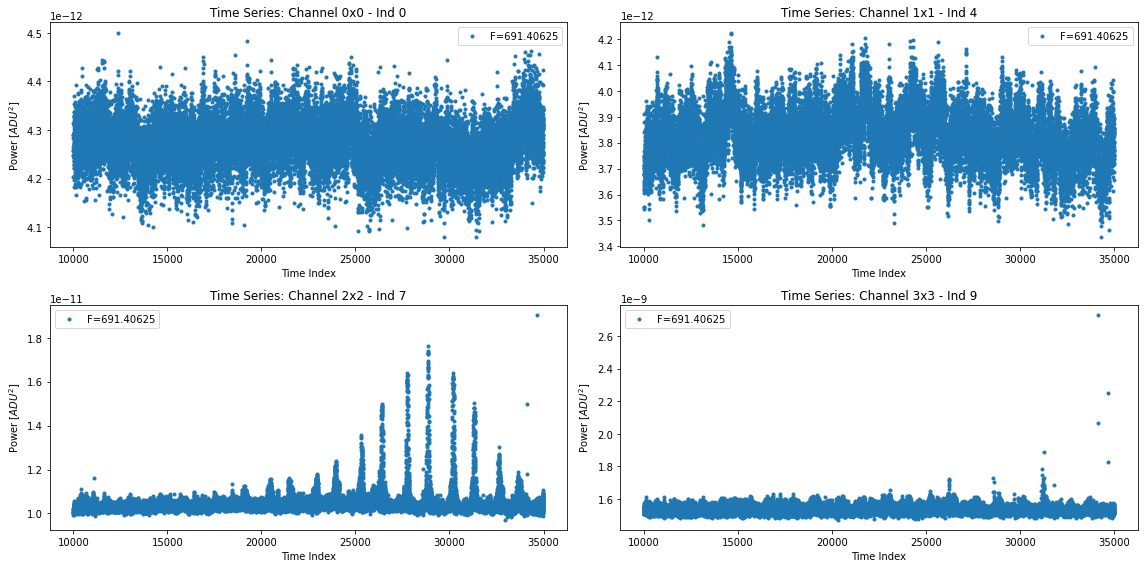

In [130]:
pu.Plot_Time_Series(NFEWconcat_NSpol,tbounds=[10000, 35000],freqlist=[278])

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [253.  31. 120. 120.]
  --> t_deltas = [-0.147 -0.369 -0.28  -0.28 ]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.2800000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []


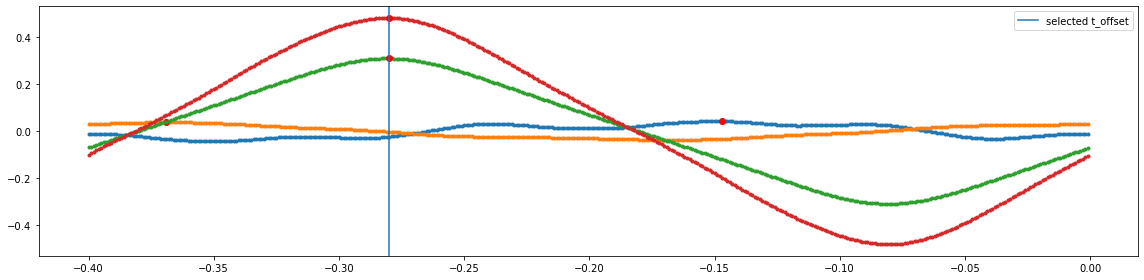

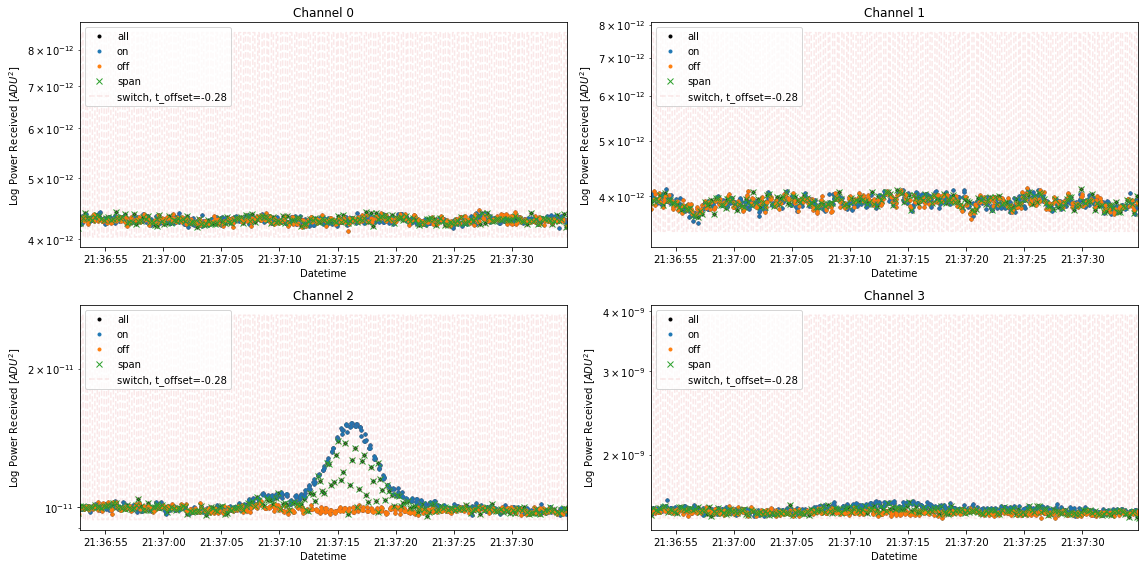

In [131]:
# using Morgan's input parameters for extract_source_pulses
# NFEWconcat.Extract_Source_Pulses(Period=0.9998e6,Dutycycle=0.5e6,t_bounds=[27200,28200],f_ind=331,minmaxpercents=[0.0001,100])

## this is the one that works!
NFEWconcat_NSpol.Extract_Source_Pulses(Period=0.4e6,Dutycycle=0.2e6,t_bounds=[27200,28200],f_ind=275,minmaxpercents=[10,100])

In [132]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
NFEWconcat_NSpol.Perform_Background_Subtraction(window_size=5)

Calculating background spectra from indices where the noise source is off.
  --> Background subtraction completed using window_size = 5


Synchronizing data from correlator and drone:
  --> Previous t_delta_dji not found
  --> Calculating via 2DGauss fitting routine:


<ipython-input-61-4e0cf3751658>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])
<ipython-input-61-4e0cf3751658>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


[[0.31383109 0.29017021]]
copolchan=0
Applying a time correction of -1.60 seconds using Channel 0 fits.


<ipython-input-61-4e0cf3751658>:166: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_CORR=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in self.t_arr_datetime[CORR_t_ind_lb:CORR_t_ind_ub]])
<ipython-input-61-4e0cf3751658>:167: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ds_drone=np.array([(np.datetime64(ts).astype(datetime.datetime).replace(tzinfo=pytz.UTC)-tsepoch).total_seconds() for ts in DRONEDATCLASS.t_arr_datetime])


  --> Variable synchronation successful, generating output plots:
[3]


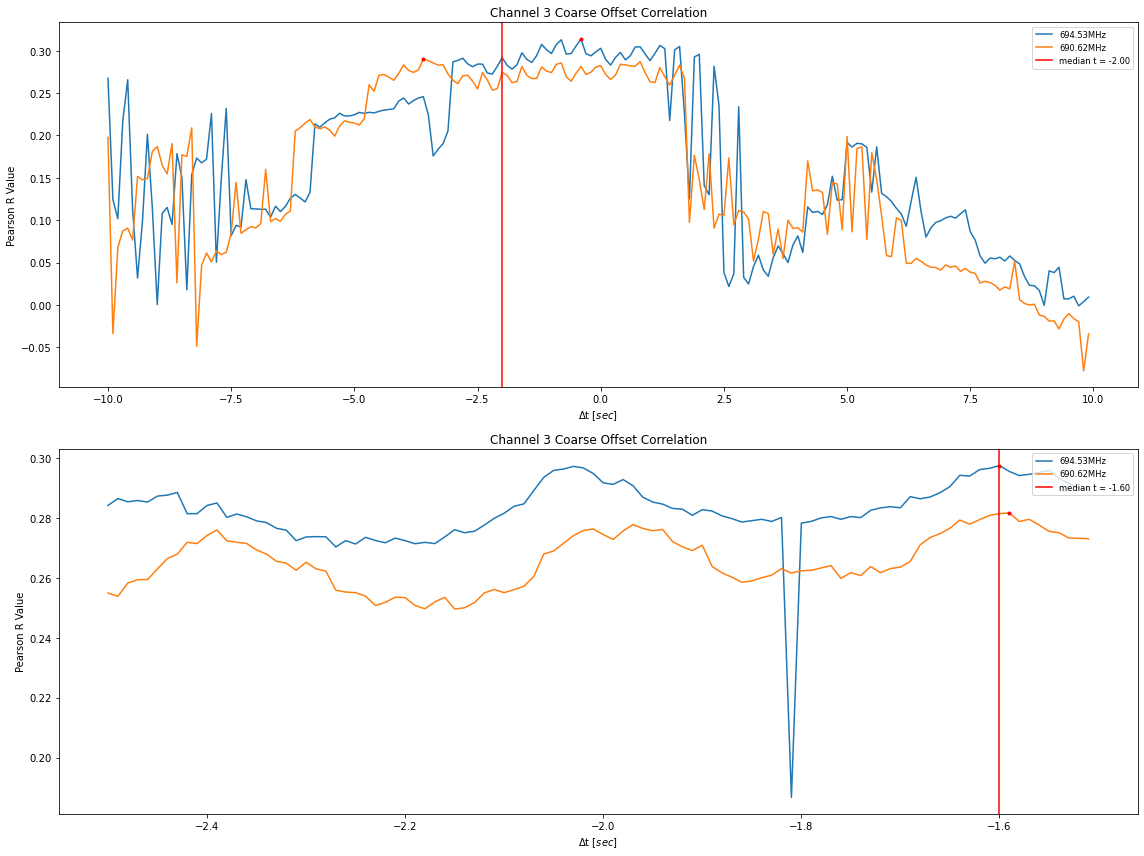

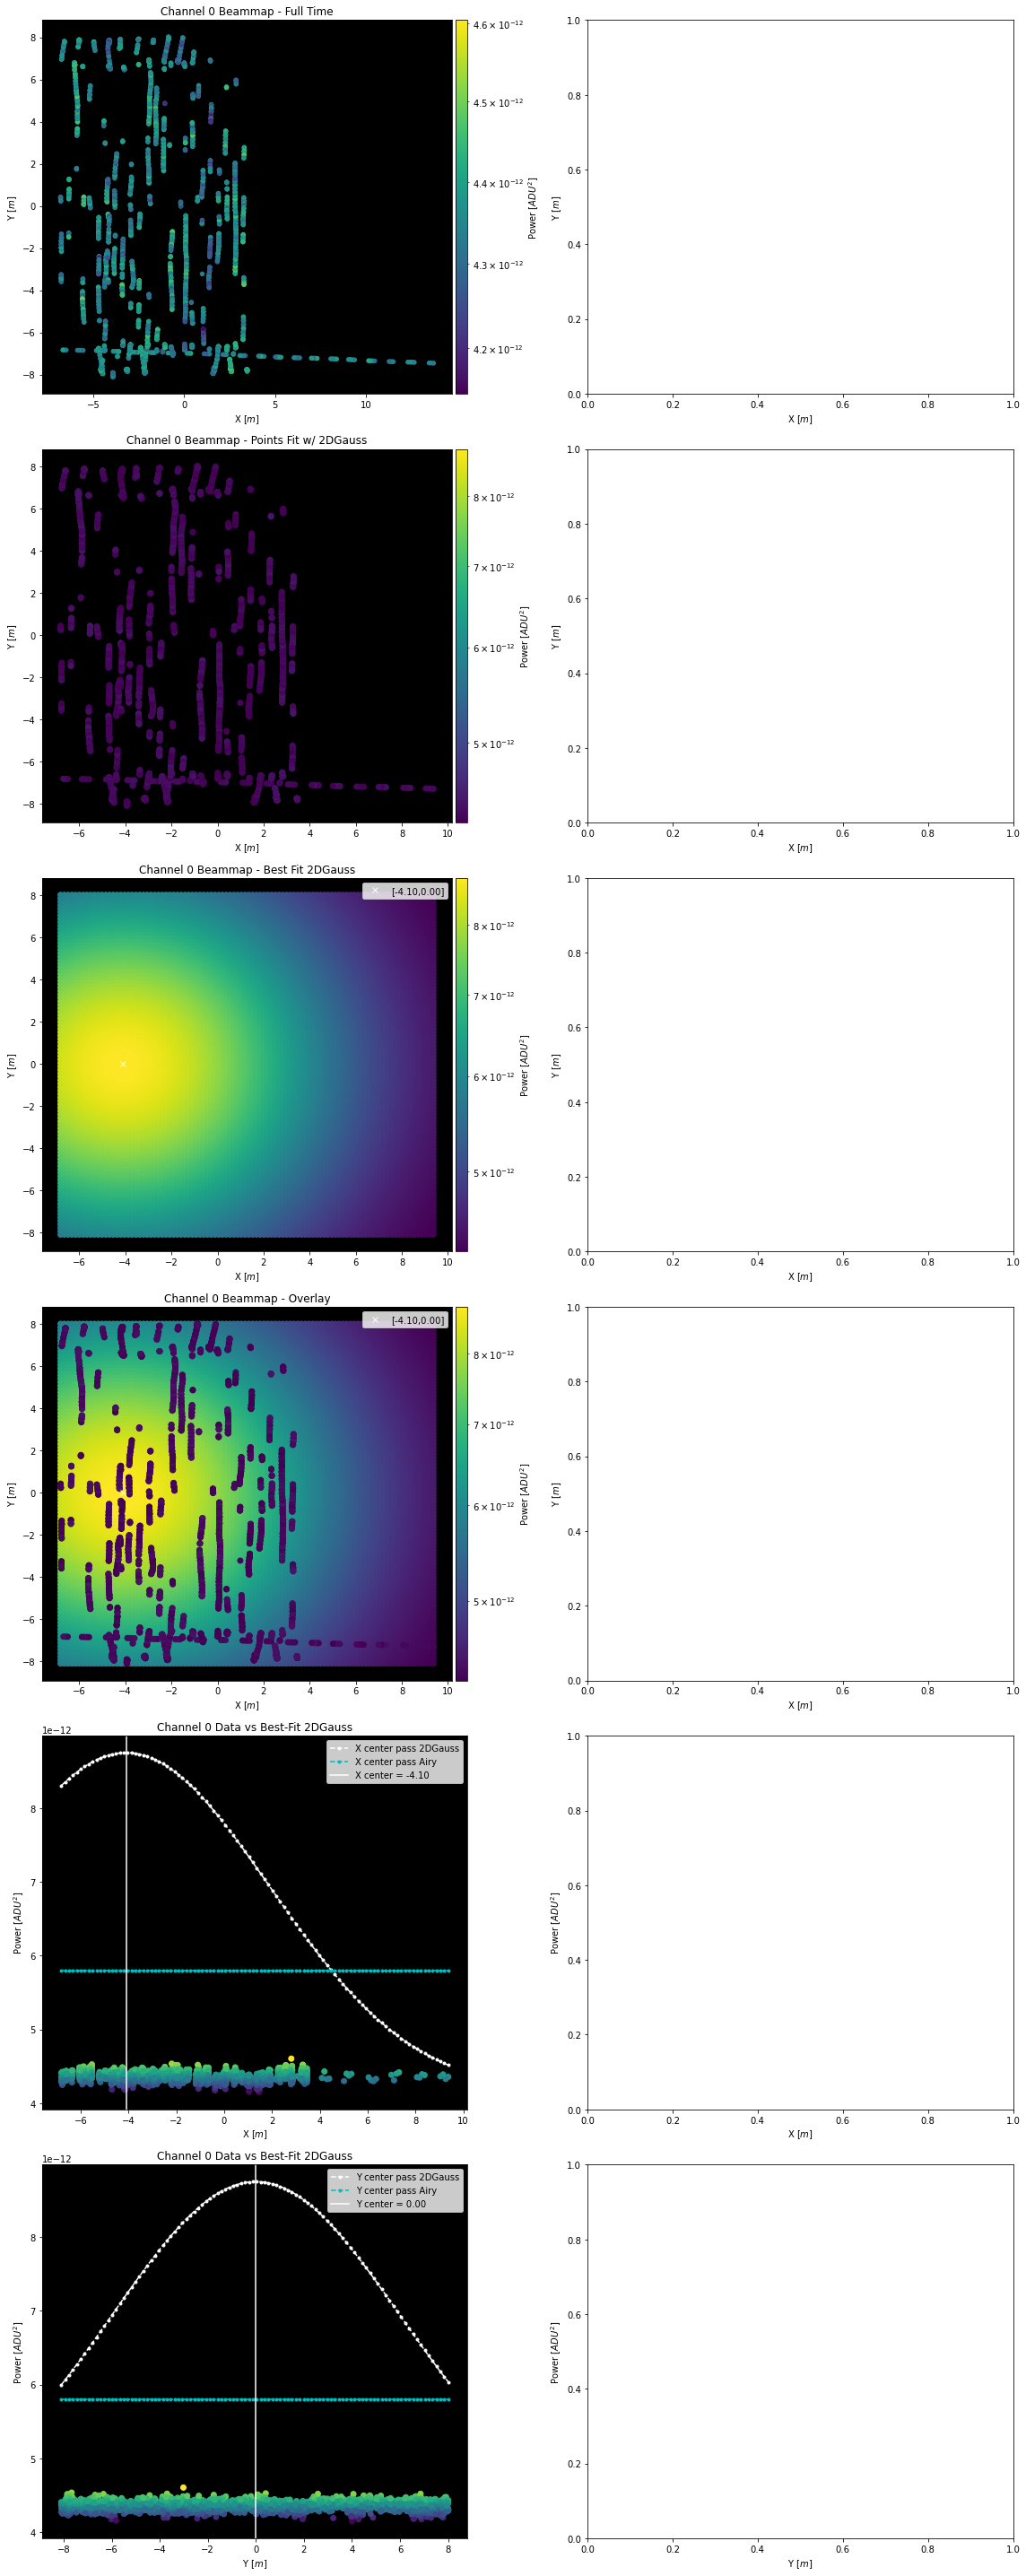

In [133]:
NFEWconcat_NSpol.Synchronization_Function(inputcorr=NFEWcorr_NSpol,inputdrone=NFEWdrone_NSpol,freqs=[270,280],\
                                    FMB_coordbounds=[10.0,10.0,10.0],FMB_ampbound=0.999,chans=[3], coarse_params=[-10.0,10.0,0.1])

## Trying the actual NS flight

In [5]:
## OBJECTIVE 2: Load Drone Data

## Read in the Drone_Data class, lets choose "FLY653.csv":
## We'll use the minimum necessary input parameters:
    # FLYTAG - the filename of the selected file
    # Drone_Directory - the directory location containing the file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # skip_rows=range(500).tolist() - this is how many rows are skipped to omit NAN values.
#dronedir='/hirax/all_drone_data/datcon_csv/'
#dronetest0825=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='FLY533.csv',site_class=gbosite)

#myfile
dronedir = '/home/am3674/JanFeb_2025_flights/'
NFNSdrone=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG='Jan-30th-2025-04-59PM-Flight-Airdata.csv',site_class=wlcsiteNS)

Initializing drone data via Airdata.csv routine: Jan-30th-2025-04-19PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.


In [6]:
## OBJECTIVE 3: Load Correlator Data

## Read in the Corr_Data class, corresponding to the "FLY653.csv" file.
## We'll use the minimum necessary input parameters:
    # Data_Directory - the directory location containing the correlator files
    # Gain_Directory - the directory location containing the gain file
    # site_class - the site config class, which we defined above as 'gbosite'
## The following input parameters will be left to their default setting:
    # Data_File_Index=None - data files to use (default --> all files)
    # Load_Gains=True
    # Fix_Gains=False - should we apply a fixed gain in each channel? (only use when known from config)
    # Apply_Gains=True - if set to False, the V arrays will contain uncalibrated "raw" data
    # Gain_Params=[1.0, 24.0] - if applying a fixed gain, the gain in each channel will be: 1.0*(10**24.0)
    # fbounds=[0, -1] - what frequency bounds should we pull from the visibility matrix?
flight_data_dir = '/hirax/NF_flight_data'
datadir=os.path.join(flight_data_dir, '20250130T215831Z/')
gaindir=os.path.join(flight_data_dir, '20250130T211653Z_yale_portable_corr_digitalgain/')
NFNScorr=corr.Corr_Data(Data_Directory=datadir,Gain_Directory=gaindir,site_class=wlcsiteNS, use_ctime=True, crossmap=[8])

Initializing Correlator Class using:
  --> /hirax/NF_flight_data/20250130T211751Z/
  --> Arrays initialized with shape (144, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0143/0143
  --> Finished. Reshaping arrays.


In [7]:
NFEWcorr.n_channels

4

0.46758389472961426
[Timestamp('2025-01-30 21:21:17.900000+0000', tz='UTC')
 Timestamp('2025-01-30 21:21:18+0000', tz='UTC')
 Timestamp('2025-01-30 21:21:18.100000+0000', tz='UTC') ...
 Timestamp('2025-01-30 21:48:48.200000+0000', tz='UTC')
 Timestamp('2025-01-30 21:48:48.300000+0000', tz='UTC')
 Timestamp('2025-01-30 21:48:48.300000+0000', tz='UTC')]
[datetime.datetime(2025, 1, 30, 21, 17, 51, 971613, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 17, 52, 13556, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 17, 52, 55499, tzinfo=<UTC>) ...
 datetime.datetime(2025, 1, 30, 21, 43, 38, 34010, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 43, 38, 75953, tzinfo=<UTC>)
 datetime.datetime(2025, 1, 30, 21, 43, 38, 117897, tzinfo=<UTC>)]


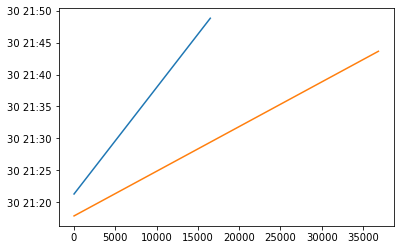

In [8]:
start = time.time()


## Just to illustrate that these two files correspond to the same times, let's plot their datetime arrays:
plot(NFEWdrone.t_arr_datetime)
plot(NFEWcorr.t_arr_datetime)

end = time.time()
print(end - start)
print(NFEWdrone.t_arr_datetime)
print(NFEWcorr.t_arr_datetime)